In [1]:
# ─────────────────────────────────────────────────────────────
#  Configuración inicial - Instalación de dependencias
# ─────────────────────────────────────────────────────────────
# !pip install plantuml requests ipython -q

import os
import tempfile
from pathlib import Path
from IPython.display import Image, display, Markdown, Code

# ── Renderizador de diagramas PlantUML ──
try:
    from plantuml import PlantUML
    PLANTUML_SERVER = PlantUML(url='http://www.plantuml.com/plantuml/img/')
    _plantuml_available = True
except ImportError:
    _plantuml_available = False

def render_plantuml(plantuml_code, width=800):
    full_code = plantuml_code.strip()
    if not full_code.startswith('@startuml'):
        full_code = '@startuml\n' + full_code
    if not full_code.rstrip().endswith('@enduml'):
        full_code = full_code.rstrip() + '\n@enduml'

    if _plantuml_available:
        try:
            img_data = PLANTUML_SERVER.processes(full_code)
            display(Image(data=img_data, width=width))
            return
        except Exception:
            pass

    print('[WARN] No se pudo renderizar el diagrama (sin conexion al servidor PlantUML).')
    print('Codigo fuente:')
    print('```plantuml')
    print(full_code)
    print('```')

print('Configuracion completada. Los diagramas PlantUML se renderizaran en linea.')

Configuracion completada. Los diagramas PlantUML se renderizaran en linea.


# 1. ¿Qué es un diagrama de clases?

Llevo muchos trabajando en análisis y diseño de sistemas, y si hay un diagrama que nunca falta en mis proyectos, ese es el diagrama de clases. No es casualidad: es la herramienta más poderosa que tenemos los ingenieros de software para responder a la pregunta fundamental de todo sistema: *¿cómo está construido?*

Si el diagrama de casos de uso nos cuenta las historias que el sistema debe contar junto a sus actores, el diagrama de clases nos revela la anatomía interna de los protagonistas de esas historias. Es el modelo que captura la estructura estática del software: las clases que lo componen, los datos que almacenan, los comportamientos que exponen y las relaciones que tejen entre ellas. En esencia, mientras los casos de uso responden a *¿qué hace el sistema?*, el diagrama de clases responde a *¿cómo está construido internamente para poder hacerlo?*.

En este primer tema sobre el modelado estructural, exploraremos el propósito del diagrama de clases dentro de UML, su naturaleza estática frente a los diagramas de comportamiento, los elementos fundamentales que aparecen en él y cómo PlantUML nos proporciona una sintaxis sencilla e intuitiva para dibujarlo y, sobre todo, para mantenerlo sincronizado con el resto de la documentación del proyecto.

## 1.1. El rol del diagrama de clases en UML

Cuando empecé en esta profesión, recuerdo que los equipos de desarrollo dibujaban diagramas en pizarras que se borraban al terminar la reunión. No había trazabilidad, no había versiones, no había rigor. Con la adopción de UML y, más tarde, de herramientas basadas en texto como PlantUML, el modelado estructural dejó de ser un ejercicio efímero para convertirse en un artefacto de ingeniería.

UML (Lenguaje Unificado de Modelado) organiza sus diagramas en dos grandes familias: los **diagramas de comportamiento** (casos de uso, secuencia, actividades, estados) y los **diagramas de estructura** (clases, objetos, componentes, despliegue, paquetes). El diagrama de clases es, sin duda, el más emblemático de los diagramas estructurales.

Su función principal es describir los tipos de objetos que existen en el sistema y las relaciones estáticas que existen entre ellos. No muestra cómo los objetos colaboran a lo largo del tiempo —eso es tarea de los diagramas de secuencia o de comunicación—, sino qué piezas componen el sistema y cómo están conectadas de manera permanente. Podemos pensarlo como el plano de ingeniería que los desarrolladores consultan para saber qué clases deben programar, qué atributos contiene cada una, qué métodos ofrecen y cómo se relacionan con otras clases.

## 1.2. Vista estática vs. vista dinámica

Para un ingeniero de software, es crucial distinguir la perspectiva estática de la dinámica. La vista estática —el diagrama de clases— es como una fotografía de la arquitectura del sistema: captura su esqueleto en un momento dado, independientemente de los flujos de ejecución. La vista dinámica —los diagramas de secuencia, de actividades, de estados— muestra cómo ese esqueleto cobra vida para cumplir un caso de uso concreto.

Ambas vistas se complementan. Un caso de uso como "Realizar Pedido" especifica una secuencia de interacciones entre un actor y el sistema. Cuando analizamos esa especificación textual para derivar el diagrama de clases, nos preguntamos: *¿qué objetos necesito para que esta historia sea posible?* Surgirán entonces clases como `Pedido`, `Cliente`, `Producto`, `Dirección`, `Pago`. Cada una de ellas aparecerá como un rectángulo en el diagrama de clases. Los atributos de esas clases (por ejemplo, `fechaPedido`, `total`) provienen de los datos que el caso de uso menciona o manipula. Los métodos (`calcularTotal()`, `confirmar()`) se corresponden con las acciones que el sistema debe ejecutar en los pasos del flujo.

Esta derivación desde el análisis funcional (casos de uso) hacia el modelo estructural (clases) es una de las habilidades más importantes que desarrollarán como ingenieros de software, y la abordaremos en profundidad en el tema 5 de este bloque. Por ahora, quédense con la idea de que el diagrama de clases no se inventa de la nada; debe surgir como respuesta a las necesidades funcionales documentadas en los casos de uso.

## 1.3. Elementos básicos de un diagrama de clases

Todo diagrama de clases se construye con un vocabulario reducido pero poderoso. Los elementos que aparecen una y otra vez son:

- **Clase**: representada como un rectángulo dividido en tres compartimentos (nombre, atributos, métodos). Es la abstracción de un concepto del dominio del problema o de la solución. Por ejemplo, `Cliente`, `Factura`, `ControladorPago`.
- **Estado**: una propiedad, atributo o característica de la clase. Tiene un nombre y un tipo. En los diagramas puede indicarse también la visibilidad (`+` público, `-` privado, `#` protegido, `~` paquete) y un valor por defecto. Ejemplo: `- nombre: String`.
- **Comportamiento**: una operación, método o función que la clase sabe realizar. También lleva visibilidad, nombre, parámetros entre paréntesis y tipo de retorno. Ejemplo: `+ calcularTotal(): double`.
- **Relación**: una conexión semántica entre dos o más clases. Hay varios tipos —asociación, agregación, composición, herencia, realización, dependencia— y cada uno expresa un matiz distinto sobre la naturaleza del vínculo. Las estudiaremos en detalle en el tema 3.

## 1.4. Más allá del código: el diagrama de clases como artefacto de comunicación

El diagrama de clases no solo sirve para generar código o para documentar la arquitectura. Es, sobre todo, un instrumento de diálogo. Cuando un arquitecto de software propone una estructura de clases, la plasma en un diagrama para que el equipo de desarrollo la revise, la cuestione y la mejore. Cuando un desarrollador nuevo se incorpora al proyecto, el diagrama de clases le ofrece un mapa de navegación por el código fuente. Cuando se discute un cambio de requisitos, se puede evaluar su impacto observando qué clases serían afectadas.

PlantUML, con su enfoque basado en texto, convierte este artefacto en algo vivo y versionable. La guía de referencia que estamos utilizando dedica un capítulo completo (páginas 57 a 98) a los diagramas de clases, mostrando cómo declarar clases, atributos, métodos, relaciones, paquetes y todo tipo de personalizaciones visuales mediante `skinparam`. La capacidad de escribir un diagrama de clases como un archivo `.puml`, almacenarlo en Git y regenerarlo cada vez que se modifica elimina la brecha entre documentación y realidad que tanto aqueja a los proyectos de software.

## 1.5. Cómo PlantUML nos ayuda a modelar la estructura estática

La sintaxis de PlantUML para diagramas de clases es notablemente sencilla e intuitiva. Para declarar una clase basta con escribir su nombre, opcionalmente precedido de la palabra `class`. Si queremos añadir atributos y métodos, utilizamos los dos puntos `:` o las llaves `{}` para agruparlos. Las relaciones se dibujan con combinaciones de guiones, puntos y flechas, cada una con su significado específico.

Un ejemplo mínimo:

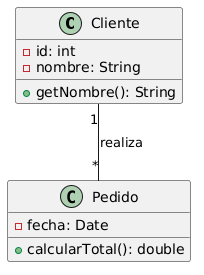

In [2]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente {
  - id: int
  - nombre: String
  + getNombre(): String
}
class Pedido {
  - fecha: Date
  + calcularTotal(): double
}
Cliente "1" -- "*" Pedido : realiza
@enduml'''

render_plantuml(plantuml_code)

En este fragmento, definimos dos clases con sus atributos y métodos, y las vinculamos mediante una asociación con multiplicidad. La herramienta generará automáticamente el diagrama correspondiente. Como la especificación está en texto, cualquier miembro del equipo puede modificarla sin necesidad de instalar software gráfico, y los cambios quedan registrados en el sistema de control de versiones.

> **UML estándar vs. PlantUML:** Es importante distinguir entre la notación UML (el estándar) y la sintaxis de PlantUML (una implementación concreta). En UML estándar, una clase se dibuja como un rectángulo con tres compartimentos y la asociación como una línea simple con etiquetas. En PlantUML *escribimos* `Cliente "1" -- "*" Pedido : realiza` y la herramienta genera automáticamente el rectángulo, los compartimentos y la línea. La sintaxis de PlantUML es una codificación textual del estándar UML, no UML en sí misma. Esto significa que los conceptos que aprendan (multiplicidad, visibilidad, tipos de relación) son transferibles a cualquier otra herramienta UML (Enterprise Architect, Visual Paradigm, etc.).

## 1.6. Niveles de abstracción: análisis vs. diseño

Una distinción fundamental que debe acompañarlos desde el primer día es comprender que un diagrama de clases puede dibujarse en diferentes niveles de abstracción, y que cada nivel tiene un propósito y una audiencia distintos:

- **Diagrama de clases de dominio (análisis):** También llamado modelo conceptual, se centra en las entidades del negocio y sus relaciones, sin ningún detalle técnico. Las clases reflejan conceptos del mundo real (como `Cliente`, `Pedido`, `Producto`) y se omiten tipos de datos precisos, visibilidad, métodos de infraestructura y cualquier referencia a la tecnología de implementación. Es el modelo que se discute con los expertos del negocio para validar la comprensión del dominio. Ejemplo: una clase `Cliente` con un atributo `nombre` (sin tipo) y un método `realizarPedido()` (sin firma exacta).

- **Diagrama de clases de diseño:** Incluye tipos concretos (`String`, `int`, `double`), visibilidad (`+`, `-`, `#`), métodos con parámetros y retornos definidos, y clases técnicas como controladores, repositorios o servicios. Es el modelo que guía a los desarrolladores durante la implementación. Ejemplo: `Cliente` con `- nombre: String` y `+ realizarPedido(productos: List<Producto>): Pedido`.

- **Diagrama de clases de arquitectura:** Muestra solo los paquetes principales y sus dependencias, omitiendo el detalle de las clases individuales. Es útil para discutir la estructura de alto nivel del sistema con arquitectos y stakeholders técnicos.

A lo largo de este bloque trabajaremos principalmente en los niveles de análisis y diseño. Cuando vean un ejemplo sin tipos ni visibilidad, estarán en modo análisis; cuando aparezcan `+`, `-` y tipos concretos, estarán en modo diseño. Elegir el nivel adecuado en cada momento evita sobrecargar prematuramente el modelo y mantiene la comunicación centrada en lo esencial.

Durante los próximos temas, profundizaremos en cada uno de los componentes del diagrama de clases: la riqueza de las relaciones, la semántica de la agregación y la composición, el papel de las interfaces y las clases abstractas, y, muy especialmente, el proceso de derivación desde los casos de uso. Al final de este bloque, serán capaces de leer y escribir diagramas de clases con soltura, y habrán incorporado a su caja de herramientas una técnica esencial para el diseño de software robusto y bien comunicado.

### Actividades propuestas — Tema 1

1. **Identificar clases:** Lea la siguiente descripción: "En una biblioteca, los socios pueden tomar prestados libros. Cada libro tiene un título, autor y número de ejemplares. Un socio puede tener hasta 5 libros prestados simultáneamente." Identifique las clases candidatas, sus posibles atributos y las relaciones entre ellas. ¿Esto es análisis o diseño? Justifique.
2. **UML vs. PlantUML:** Tome el ejemplo mínimo de la sección 1.5 y modifique el nombre de la asociación, la multiplicidad y añada una tercera clase. Dibuje el diagrama resultante en su cabeza primero (notación UML estándar) y luego escríbalo en PlantUML para verificar.
3. **Nivel de abstracción:** Para el caso de "Restaurante — Comanda — Plato", dibuje dos versiones: una de dominio (solo nombres de clases y relaciones) y otra de diseño (con atributos, tipos y visibilidad).

# 2. Clases, atributos y métodos: los bloques de construcción del modelo estructural

A lo largo de los años he visto a muchos estudiantes y desarrolladores novatos lanzarse a dibujar diagramas de clases sin tener claros los fundamentos. Se centran en las relaciones —que es lo más vistoso— y descuidan lo esencial: definir correctamente qué es cada clase, qué datos guarda y qué sabe hacer. Es como construir una casa sin tener claros los ladrillos. En este tema vamos a cimentar bien esos fundamentos.

Si el diagrama de clases es el plano del sistema, las clases son sus ladrillos, y los atributos y métodos, las vetas y la argamasa que les dan consistencia y propósito. Cada clase encapsula un concepto del dominio —una entidad, un rol, un proceso— y lo dota de **estado** (atributos) y **comportamiento** (métodos). Dominar su notación y su semántica es el primer paso para construir modelos estructurales que sean fieles a la realidad del negocio y útiles para quienes deben implementarlos.

En este tema desgranaremos cada uno de estos elementos, revisaremos cómo la guía de PlantUML nos permite declararlos con precisión y flexibilidad, y exploraremos las variantes que UML ofrece para enriquecer la expresión del diseño: visibilidad, miembros estáticos, miembros abstractos y organización avanzada del cuerpo de la clase.

## 2.1. La clase: mucho más que un rectángulo con nombre

En UML, una clase se representa como un rectángulo dividido en tres compartimentos. El superior contiene el nombre de la clase (y opcionalmente estereotipos como `<<entity>>`, `<<control>>` o `<<boundary>>`). El compartimento central aloja los atributos, y el inferior, los métodos. Esta división tripartita es el estándar visual, pero PlantUML es capaz de generar automáticamente los compartimentos a partir de una declaración textual.

La declaración más simple de una clase es simplemente escribir su nombre:

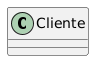

In [3]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente
@enduml'''

render_plantuml(plantuml_code)

Esto dibuja un rectángulo con el nombre "Cliente" y los compartimentos de atributos y métodos vacíos. Sin embargo, rara vez querremos una clase sin contenido. La guía de PlantUML (páginas 60-63) detalla varias maneras de añadir miembros a una clase: usando dos puntos para declaraciones sueltas, o bien llaves `{}` para agrupar atributos y métodos de forma más ordenada.

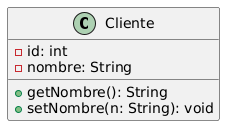

In [6]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente {
  - id: int
  - nombre: String
  + getNombre(): String
  + setNombre(n: String): void
}
@enduml'''

render_plantuml(plantuml_code)

## 2.2. Atributos: el estado que perdura

Un atributo es una propiedad que caracteriza a los objetos de una clase. Toda instancia de `Cliente` tendrá un valor para `id` y otro para `nombre`. Los atributos representan el **estado** del sistema en un momento dado, y suelen corresponderse con columnas de una base de datos, campos de un formulario o datos que fluyen entre componentes.

En PlantUML, los atributos se declaran dentro de las llaves de la clase o bien con la notación `NombreClase : atributo`. La sintaxis completa incluye, por este orden:

1. **Visibilidad**: `+` (público), `-` (privado), `#` (protegido), `~` (paquete).  
2. **Nombre**: un identificador significativo.  
3. **Tipo**: separado por dos puntos (opcional pero recomendable).  
4. **Multiplicidad**: entre corchetes si se trata de una colección.  
5. **Valor por defecto**: tras un signo igual (opcional).  
6. **Propiedades adicionales**: entre llaves, como `{ordered}`, `{unique}`, `{readOnly}`.

Ejemplo de un atributo completo:

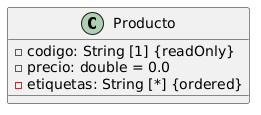

In [7]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Producto {
  - codigo: String [1] {readOnly}
  - precio: double = 0.0
  - etiquetas: String [*] {ordered}
}
@enduml'''

render_plantuml(plantuml_code)

Aquí `codigo` es privado, de tipo `String`, obligatorio y de solo lectura. `precio` es un `double` con valor por defecto 0.0. `etiquetas` es una lista ordenada de cadenas. La guía de PlantUML permite omitir cualquier parte que no sea relevante en el nivel de abstracción en que estemos modelando; en fases tempranas de diseño, podemos mostrar solo los nombres de los atributos sin preocuparnos aún por los tipos.

Además de `{ordered}`, `{unique}` y `{readOnly}`, UML permite otras restricciones en atributos y asociaciones que enriquecen la semántica del modelo:

| Restricción | Significado | Ejemplo en atributo | Ejemplo en asociación |
|-------------|-------------|---------------------|----------------------|
| `{ordered}` | Los elementos mantienen un orden específico | `- etiquetas: String [*] {ordered}` | `0..* {ordered}` en el extremo de una asociación |
| `{unique}` | No se permiten elementos duplicados | `- codigosUnicos: String [*] {unique}` | `* {unique}` en una colección de elementos |
| `{readOnly}` | El valor no puede modificarse tras la creación | `- fechaCreacion: Date {readOnly}` | No aplica |
| `{bag}` | Colección que permite duplicados pero sin orden | `- elementos: String [*] {bag}` | Asociación con semántica de bolsa |
| `{sequence}` | Colección ordenada que permite duplicados | `- pasos: String [*] {sequence}` | `0..* {sequence}` en listas con repetición |
| `{subset}` | Un conjunto es subconjunto de otro | No aplica directamente | `{subset=propietarios}` sobre `usuarios` |

Estas restricciones no son meros adornos: tienen impacto directo en la implementación. `{ordered}` sugiere una `List` en Java o un array ordenado; `{unique}` sugiere un `Set`; `{readOnly}` se traduce en un campo `final` o `const`. Incluirlas en el modelo convierte el diagrama en un contrato más preciso para los desarrolladores.

## 2.3. Métodos: el comportamiento que transforma

Los métodos especifican lo que una clase sabe *hacer* (su **comportamiento**). Pueden verse como las operaciones que el sistema ejecuta cuando un actor dispara un caso de uso, pero a diferencia de los pasos de un flujo de interacción, aquí se definen de manera abstracta, sin detallar el algoritmo interno. Solo importa su firma: nombre, parámetros, tipo de retorno y visibilidad.

La notación en PlantUML es similar a la de los atributos, pero incluye paréntesis después del nombre del método (incluso si no hay parámetros) y, opcionalmente, el tipo de retorno tras dos puntos.

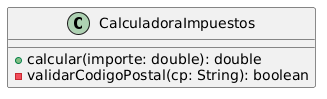

In [8]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class CalculadoraImpuestos {
  + calcular(importe: double): double
  - validarCodigoPostal(cp: String): boolean
}
@enduml'''

render_plantuml(plantuml_code)

Observen cómo `calcular` es público y devuelve un `double`, mientras que `validarCodigoPostal` es privado (quizás solo se usa internamente) y devuelve un booleano. La distinción entre métodos públicos y privados es esencial para encapsular la lógica interna y exponer solo lo que otras clases necesitan conocer.

## 2.4. Visibilidad: controlando el acceso a los miembros

Uno de los errores que más he corregido en revisiones de diseño es el abuso de la visibilidad pública. Durante años, muchos desarrolladores novatos hacen públicos todos los atributos por pereza, rompiendo el encapsulamiento. En el mundo real, la visibilidad no es un adorno: es una decisión de diseño que afecta directamente a la mantenibilidad del sistema.

UML define cuatro niveles de visibilidad para atributos y métodos, y PlantUML los representa con los siguientes caracteres:

| Símbolo | Visibilidad | Icono (si se activa) | Significado |
|---------|-------------|----------------------|-------------|
| `+` | Público | Círculo verde | Accesible desde cualquier clase |
| `-` | Privado | Cuadrado rojo | Accesible solo dentro de la propia clase |
| `#` | Protegido | Diamante azul | Accesible desde la clase y sus subclases |
| `~` | Paquete | Triángulo amarillo | Accesible desde cualquier clase del mismo paquete |

La guía de PlantUML (páginas 61-62) explica que, por defecto, los iconos de visibilidad se dibujan junto a cada atributo y método. Si el diagrama resulta demasiado recargado, podemos ocultarlos con `skinparam classAttributeIconSize 0`. En mis diagramas de alto nivel, suelo ocultarlos para mantener la limpieza; en diagramas detallados, los muestro porque son información valiosa para el desarrollador.

## 2.5. Miembros estáticos y abstractos

Dentro de una clase pueden existir miembros que pertenecen a la clase en sí misma y no a sus instancias (estáticos), o miembros que carecen de implementación y deben ser definidos por las subclases (abstractos). PlantUML nos permite marcarlos con los modificadores `{static}` y `{abstract}` (páginas 62-63). El modificador `{classifier}` es sinónimo de `{static}`.

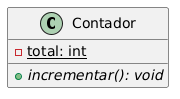

In [9]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Contador {
  {static} -total: int
  {abstract} +incrementar(): void
}
@enduml'''

render_plantuml(plantuml_code)

En este ejemplo, `total` es un atributo de clase (compartido por todas las instancias) y `incrementar()` es un método abstracto que deberán implementar las subclases. La notación UML tradicional mostraría los miembros abstractos en cursiva y los estáticos subrayados, pero PlantUML utiliza las etiquetas entre llaves para que no haya ambigüedad.

## 2.6. Organización avanzada del cuerpo de la clase

A medida que una clase acumula atributos y métodos, conviene agruparlos para facilitar la lectura. PlantUML permite insertar separadores dentro de la definición de la clase usando líneas con `--`, `..`, `==` o `__` (páginas 62-64). Cada separador puede ir seguido de un título que describa el grupo.

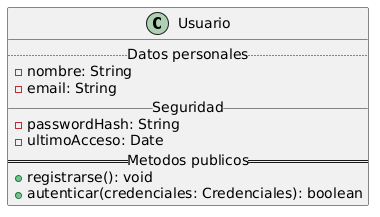

In [10]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Usuario {
  .. Datos personales ..
  - nombre: String
  - email: String
  __ Seguridad __
  - passwordHash: String
  - ultimoAcceso: Date
  == Metodos publicos ==
  + registrarse(): void
  + autenticar(credenciales: Credenciales): boolean
}
@enduml'''

render_plantuml(plantuml_code)

Esta técnica es especialmente útil para clases complejas, como las entidades de un modelo de dominio, donde hay decenas de atributos y métodos. Los separadores guían al lector hacia la información relevante sin tener que escrutar una lista interminable.

## 2.7. De los casos de uso a las clases, atributos y métodos

Aunque dedicaremos un tema completo a la derivación desde los casos de uso, conviene anticipar la conexión: cada sustantivo relevante que aparece en la especificación textual de un caso de uso es un candidato a convertirse en clase. Por ejemplo, en el flujo básico de "Realizar Pedido" encontramos "Cliente", "Producto", "Pedido", "Dirección". Estos sustantivos se convierten en las clases de nuestro modelo estructural.

Los datos que se mencionan en el flujo —"nombre del cliente", "precio del producto", "fecha del pedido"— se transforman en atributos (el **estado**). Las acciones que el sistema realiza —"calcular total", "validar stock", "confirmar pago"— dan lugar a métodos (el **comportamiento**).

Esta conexión asegura que el modelo de clases no sea una invención arbitraria, sino un reflejo fiel de lo que el sistema necesita hacer. Y puesto que tanto los casos de uso como el diagrama de clases se escriben en PlantUML, ambos artefactos pueden versionarse conjuntamente y mantenerse sincronizados sin fricción.

## 2.8. Los cuatro pilares de la programación orientada a objetos

El diagrama de clases es la expresión visual de los principios fundamentales de la programación orientada a objetos (POO). Comprender estos principios es esencial para modelar correctamente, porque cada elemento del diagrama —clase, **estado** (atributo), **comportamiento** (método), relación— es una manifestación de uno o más de estos pilares.

A continuación exploramos cada pilar con ejemplos prácticos en Python que ilustran cómo se traducen del diagrama UML al código real.

---

### 2.8.1. Abstracción

La abstracción consiste en capturar las características esenciales de un concepto del mundo real, ignorando los detalles irrelevantes para el propósito del sistema. En el diagrama de clases, cada clase es una abstracción: `Cliente` no modela todos los aspectos de una persona real, solo aquellos que interesan al sistema (nombre, email, pedidos). El **estado** (atributos) y el **comportamiento** (métodos) representan la información y las operaciones relevantes, omitiendo todo lo demás.

**Ejemplo en Python:**

In [11]:
# ── Abstracción ──────────────────────────────────────────────
# La clase Cliente abstrae solo el estado y comportamiento relevantes
# del concepto "cliente" para el sistema de comercio electrónico.
class Cliente:
    def __init__(self, id_cliente: int, nombre: str, email: str):
        self._id = id_cliente          # estado
        self._nombre = nombre          # estado
        self._email = email            # estado
        self._pedidos = []             # estado

    def agregar_pedido(self, pedido):  # comportamiento
        self._pedidos.append(pedido)

    def obtener_historial(self):       # comportamiento
        return self._pedidos.copy()

# El mundo real tiene muchos más atributos de una persona
# (altura, peso, color de ojos, etc.), pero NO son relevantes
# para el sistema. Eso es abstracción: quedarse con lo esencial.


---

### 2.8.2. Encapsulamiento

El encapsulamiento agrupa datos (**estado**) y operaciones (**comportamiento**) dentro de una clase, y controla el acceso a ellos mediante la visibilidad. Los atributos privados (`-` en UML, con guion bajo `_` en Python) solo son accesibles desde la propia clase, protegiendo la integridad del estado interno. Los métodos públicos (`+` en UML) definen la interfaz mediante la cual otras clases interactúan con ella.

En el diagrama de clases, la visibilidad (`+`, `-`, `#`, `~`) es la representación directa de este pilar. Python no tiene modificadores de acceso estrictos, pero por convención:
- `_atributo` = privado (equivale a `-` en UML)
- `__atributo` = name-mangling (ocultación más fuerte)
- Sin guion bajo = público (equivale a `+` en UML)

**Ejemplo en Python:**

In [12]:
# ── Encapsulamiento ──────────────────────────────────────────
class CuentaBancaria:
    def __init__(self, titular: str, saldo_inicial: float = 0.0):
        self._titular = titular           # estado privado
        self.__saldo = saldo_inicial      # estado privado (name mangling)

    # comportamiento público: interfaz controlada
    def depositar(self, monto: float):
        if monto > 0:
            self.__saldo += monto

    def retirar(self, monto: float) -> bool:
        if 0 < monto <= self.__saldo:
            self.__saldo -= monto
            return True
        return False

    def consultar_saldo(self) -> float:   # comportamiento público
        return self.__saldo

# Uso: el estado interno está protegido, solo se accede
# a través del comportamiento público definido.
cta = CuentaBancaria("Ana", 1000)
cta.depositar(500)
print(f"Saldo actual: {cta.consultar_saldo()}")  # 1500
# cta.__saldo  ← Esto daría error: el atributo está encapsulado


Saldo actual: 1500


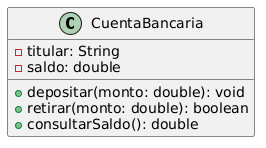

In [13]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class CuentaBancaria {
  - titular: String
  - saldo: double
  + depositar(monto: double): void
  + retirar(monto: double): boolean
  + consultarSaldo(): double
}
@enduml'''

render_plantuml(plantuml_code)

---

### 2.8.3. Herencia

La herencia permite que una clase (subclase) reutilice y extienda el **estado** y el **comportamiento** de otra (superclase). En el diagrama de clases, se representa con la relación `<|--` (o la palabra `extends` en PlantUML). La herencia modela relaciones "es-un": `Coche` es un `Vehiculo`, `Factura` es un `DocumentoPago`.

Promueve la reutilización del código y facilita la organización jerárquica de los conceptos. La subclase hereda automáticamente el estado y comportamiento de la superclase, y puede:
- Añadir nuevo estado y comportamiento propio.
- Redefinir (sobrescribir) comportamiento heredado.

**Ejemplo en Python:**

In [14]:
# ── Herencia ────────────────────────────────────────────────
class Vehiculo:
    def __init__(self, matricula: str):
        self._matricula = matricula    # estado heredado
        self._velocidad = 0            # estado heredado

    def acelerar(self, incremento: int):   # comportamiento heredado
        self._velocidad += incremento

    def obtener_velocidad(self) -> int:    # comportamiento heredado
        return self._velocidad

class Coche(Vehiculo):  # Coche ES-UN Vehiculo
    def __init__(self, matricula: str, num_puertas: int):
        super().__init__(matricula)    # reutiliza estado del padre
        self._num_puertas = num_puertas  # nuevo estado propio

    def abrir_maletero(self):           # nuevo comportamiento propio
        print("Maletero abierto")

    def acelerar(self, incremento: int): # comportamiento redefinido
        # El coche acelera con un límite de seguridad
        if self._velocidad + incremento <= 200:
            super().acelerar(incremento)

class Moto(Vehiculo):  # Moto ES-UN Vehiculo
    def __init__(self, matricula: str, tiene_sidecar: bool):
        super().__init__(matricula)
        self._tiene_sidecar = tiene_sidecar

    def hacer_caballito(self):           # comportamiento propio
        print("Haciendo caballito...")


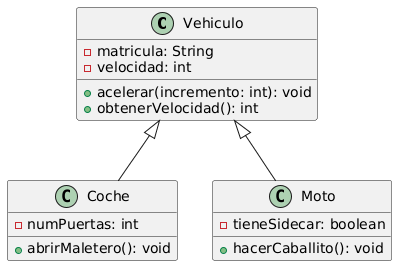

In [15]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Vehiculo {
  - matricula: String
  - velocidad: int
  + acelerar(incremento: int): void
  + obtenerVelocidad(): int
}
class Coche extends Vehiculo {
  - numPuertas: int
  + abrirMaletero(): void
}
class Moto extends Vehiculo {
  - tieneSidecar: boolean
  + hacerCaballito(): void
}
@enduml'''

render_plantuml(plantuml_code)

---

### 2.8.4. Polimorfismo

El polimorfismo permite que objetos de diferentes clases respondan al mismo mensaje de maneras específicas para cada clase. En el diagrama de clases, se manifiesta a través de las interfaces y las clases abstractas: una interfaz `IPagable` declara el método `calcularImporte()`, y cada clase que la realiza (`Factura`, `Recibo`, `NotaCredito`) proporciona su propia implementación.

El código cliente puede tratar objetos de todas estas clases de manera uniforme a través de la interfaz, sin conocer los detalles concretos de cada implementación.

**Ejemplo en Python:**

In [16]:
# ── Polimorfismo ────────────────────────────────────────────
from abc import ABC, abstractmethod

class Pagable(ABC):  # Interfaz = contrato puro
    @abstractmethod
    def calcular_importe(self) -> float:
        pass

    @abstractmethod
    def procesar_pago(self) -> bool:
        pass

class Factura(Pagable):
    def __init__(self, base: float, iva: float):
        self._base = base
        self._iva = iva

    def calcular_importe(self) -> float:   # cada clase implementa
        return self._base * (1 + self._iva)

    def procesar_pago(self) -> bool:
        print(f"Procesando pago de factura: {self.calcular_importe():.2f}")
        return True

class Recibo(Pagable):
    def __init__(self, monto: float):
        self._monto = monto

    def calcular_importe(self) -> float:   # su propia versión
        return self._monto

    def procesar_pago(self) -> bool:
        print(f"Procesando pago de recibo: {self.calcular_importe():.2f}")
        return True

# Código polimórfico: trata todos como Pagable sin saber cuál es
def cobrar(documento: Pagable):
    print(f"Importe: {documento.calcular_importe():.2f}")
    documento.procesar_pago()

# Uso
factura = Factura(1000, 0.21)
recibo = Recibo(50)
cobrar(factura)   # Comportamiento específico de Factura
cobrar(recibo)    # Comportamiento específico de Recibo


Importe: 1210.00
Procesando pago de factura: 1210.00
Importe: 50.00
Procesando pago de recibo: 50.00


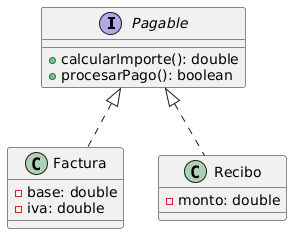

In [17]:
# Diagrama PlantUML
plantuml_code = '''@startuml
interface Pagable {
  + calcularImporte(): double
  + procesarPago(): boolean
}
class Factura implements Pagable {
  - base: double
  - iva: double
}
class Recibo implements Pagable {
  - monto: double
}
@enduml'''

render_plantuml(plantuml_code)

---

### Relación entre los pilares y el diagrama de clases

Estos cuatro pilares no son conceptos teóricos aislados; se reflejan directamente en la notación que están aprendiendo:

| Pilar | Representación en el diagrama UML | Beneficio principal |
|-------|----------------------------------|-------------------|
| **Abstracción** | Cada clase modela solo lo relevante del dominio | Simplifica la complejidad del mundo real |
| **Encapsulamiento** | Visibilidad `+`, `-`, `#`, `~` en atributos y métodos | Protege la integridad del estado interno |
| **Herencia** | Relación `<|--` o `extends` entre clases | Reutilización de estado y comportamiento |
| **Polimorfismo** | Interfaces y clases abstractas con realización `<|..` | Flexibilidad para tratar objetos de forma unificada |

Cuando dibujan una clase con atributos privados (estado encapsulado) y métodos públicos (comportamiento accesible), están aplicando encapsulamiento. Cuando usan herencia o realización de interfaces, están aplicando herencia y polimorfismo. Cuando deciden qué incluir y qué omitir en una clase, están aplicando abstracción. El diagrama de clases es, en este sentido, el plano arquitectónico de la POO.

Con este dominio de las clases, su **estado** y su **comportamiento**, estamos listos para abordar el tejido que une unas clases con otras: las relaciones estructurales, que son el tema al que dedicaremos la siguiente sección.

### Actividades propuestas — Tema 2

1. **Modelar una clase:** Dado el concepto "Factura" con los datos: número, fecha, cliente, base imponible, IVA, total, y las operaciones: calcular total, emitir, anular. Modele la clase en PlantUML con visibilidad, tipos y al menos un miembro estático (p. ej., un contador de facturas).
2. **Identificar miembros:** Para la clase `CuentaBancaria`, determine qué atributos (estado) y métodos (comportamiento) debería tener. ¿Cuáles deben ser públicos? ¿Cuáles privados? ¿Tiene algún miembro estático? Modele su respuesta en PlantUML.
3. **4 pilares de POO:** Explique con sus propias palabras cómo se reflejan la abstracción, el encapsulamiento, la herencia y el polimorfismo en la siguiente clase PlantUML: `class Vehiculo { - velocidad: int; + acelerar(): void }` y `class Coche extends Vehiculo { + abrirMaletero(): void }`. Implemente ambas clases en Python como ejercicio adicional.

# 3. Relaciones entre clases

He dedicado buena parte de mi carrera a revisar diagramas de clases de equipos de desarrollo, y si hay una lección que he aprendido es esta: la mayoría de los errores de diseño no están en las clases, sino en las relaciones que se establecen entre ellas. Una relación mal elegida puede generar acoplamientos indebidos, problemas de persistencia y un mantenimiento costoso. Por eso dedico un tema entero a este asunto.

Si las clases son los nodos de nuestra red conceptual, las relaciones son los hilos que las unen y les dan sentido colectivo. Una clase aislada no basta; lo que convierte un conjunto de clases en un modelo de software es precisamente la manera en que se vinculan entre sí. UML define varios tipos de relaciones, cada una con una semántica precisa que va mucho más allá de "hay una línea entre A y B". Como ingenieros, debemos elegir la relación correcta para cada vínculo del dominio, porque esa decisión condiciona cómo se generará el código, cómo se gestionará la persistencia y cómo evolucionará el sistema ante cambios futuros.

En este tema recorreremos todos los tipos de relación que PlantUML nos permite dibujar en un diagrama de clases: asociación simple, agregación, composición, herencia, realización de interfaces y dependencia. Veremos su notación, su significado estructural, cuándo aplicar cada una y cómo expresarlas con la sintaxis textual de PlantUML.


## 3.1. La asociación simple: el vínculo semántico básico

Una asociación es una conexión estructural entre dos clases que indica que los objetos de una clase están relacionados con los objetos de la otra de forma significativa para el dominio. Es la relación más genérica y, por tanto, la más frecuente. En un diagrama de clases, se representa con una línea continua entre las dos clases.

Por ejemplo, si decimos que un `Cliente` realiza `Pedido`s, estamos afirmando que existe una asociación entre `Cliente` y `Pedido`. Esa afirmación implica que en tiempo de ejecución habrá objetos de ambas clases vinculados: cada pedido pertenece a un cliente, y un cliente puede tener múltiples pedidos.

La notación PlantUML para la asociación simple emplea dos guiones `--`. Podemos añadir un nombre a la asociación, especificar la dirección de lectura con un triángulo `>` o `<`, e indicar la multiplicidad en cada extremo.


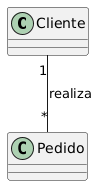

In [18]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente
class Pedido
Cliente "1" -- "*" Pedido : realiza
@enduml'''

render_plantuml(plantuml_code)

En este ejemplo, la multiplicidad `1` junto a `Cliente` indica que un pedido está asociado exactamente a un cliente. La multiplicidad `*` junto a `Pedido` significa que un cliente puede estar asociado a cero o más pedidos. La etiqueta `realiza` es opcional y aclara la naturaleza de la asociación.

Además de la multiplicidad y la etiqueta, las asociaciones pueden llevar **roles** en los extremos. Un rol es un nombre que describe cómo participa una clase en la asociación desde la perspectiva de la otra.


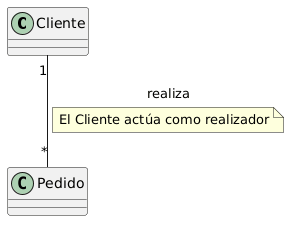

In [24]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente
class Pedido
Cliente "1" -- "*" Pedido : realiza
note on link
  El Cliente actúa como realizador
end note
@enduml'''

render_plantuml(plantuml_code)

Los roles son especialmente útiles cuando una clase se relaciona consigo misma (asociación reflexiva). Por ejemplo, un empleado que tiene un supervisor que también es empleado:


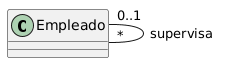

In [28]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Empleado
Empleado "0..1" -- "*" Empleado : supervisa
@enduml'''

render_plantuml(plantuml_code)

## 3.2. Agregación y composición: cuando la parte depende del todo

En muchos dominios existen relaciones "todo-parte": un pedido se compone de líneas de pedido, un departamento agrupa empleados, un vehículo consta de motor y ruedas. UML captura estos vínculos mediante dos variantes de asociación reforzada: la agregación y la composición.

### 3.2.1. Agregación (rombo blanco)

La agregación es una relación todo-parte en la que la parte **puede existir independientemente** del todo. Se representa con una línea que lleva un rombo vacío en el extremo del todo. En PlantUML, el símbolo es `o--`.


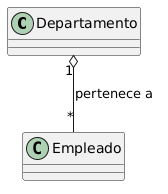

In [29]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Departamento
class Empleado
Departamento "1" o-- "*" Empleado : pertenece a
@enduml'''

render_plantuml(plantuml_code)

Aquí, un `Empleado` puede pertenecer a un `Departamento`, pero si el departamento se disuelve, el empleado no desaparece; simplemente se queda sin departamento o se reasigna a otro. La metáfora es: el todo "agrega" las partes, pero éstas conservan su identidad y ciclo de vida propios.

### 3.2.2. Composición (rombo negro)

La composición es una relación todo-parte más fuerte que la agregación. En ella, la parte **no puede existir sin el todo**. Se representa con un rombo relleno en el extremo del todo. En PlantUML, el símbolo es `*--`.


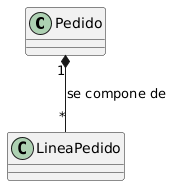

In [30]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Pedido
class LineaPedido
Pedido "1" *-- "*" LineaPedido : se compone de
@enduml'''

render_plantuml(plantuml_code)

En este caso, las líneas de pedido no tienen sentido fuera del pedido al que pertenecen. Si se elimina un pedido, sus líneas asociadas también deben desaparecer. La composición indica que la responsabilidad del ciclo de vida de las partes recae sobre el todo: el objeto compuesto crea, gestiona y destruye sus componentes.

La pregunta clave es: *¿la parte sobrevive si el todo desaparece?* Si la respuesta es sí, usen agregación. Si es no, usen composición.


## 3.3. Herencia: la relación "es-un"

La herencia —también llamada generalización— es el mecanismo que permite a una clase (la subclase o clase hija) reutilizar la estructura y el comportamiento de otra (la superclase o clase padre), especializándola o extendiéndola. La subclase hereda todos los atributos y métodos del padre, y puede añadir nuevos o redefinir los existentes.

En UML, la herencia se representa con una línea continua y una punta de flecha hueca (triángulo vacío) que apunta desde la subclase hacia la superclase. En PlantUML, el símbolo es `<|--`.


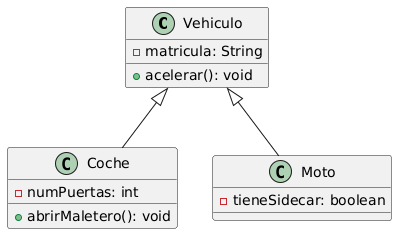

In [31]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Vehiculo {
  - matricula: String
  + acelerar(): void
}
class Coche extends Vehiculo {
  - numPuertas: int
  + abrirMaletero(): void
}
class Moto extends Vehiculo {
  - tieneSidecar: boolean
}
@enduml'''

render_plantuml(plantuml_code)

Observen que `Coche` y `Moto` heredan `matricula` y `acelerar()` de `Vehiculo`, pero cada una añade sus propias particularidades. La herencia permite tratar objetos de las subclases como si fueran del tipo padre (polimorfismo), lo que es uno de los pilares del diseño orientado a objetos.

PlantUML también permite usar la palabra clave `extends` en lugar del símbolo `<|--`, lo que puede resultar más legible para quienes prefieren una sintaxis más cercana al código:


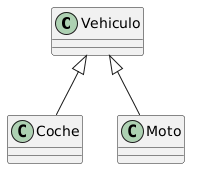

In [32]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Vehiculo
class Coche extends Vehiculo
class Moto extends Vehiculo
@enduml'''

render_plantuml(plantuml_code)

## 3.4. Realización: implementando una interfaz

La realización es la relación que existe entre una clase y la interfaz que implementa. Una interfaz define un conjunto de métodos sin implementar (un contrato), y las clases que la realizan se comprometen a proporcionar una implementación concreta para todos ellos.

En PlantUML, la interfaz se puede declarar con la palabra `interface` o con el símbolo de círculo (notación "lollipop"). La relación de realización se dibuja con una línea discontinua y una punta de flecha hueca: `<|..`.


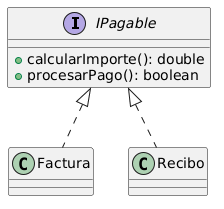

In [33]:
# Diagrama PlantUML
plantuml_code = '''@startuml
interface IPagable {
  + calcularImporte(): double
  + procesarPago(): boolean
}
class Factura implements IPagable
class Recibo implements IPagable
@enduml'''

render_plantuml(plantuml_code)

Aquí, `Factura` y `Recibo` realizan la interfaz `IPagable`. Cualquier cliente que trabaje con `IPagable` podrá tratar indistintamente con facturas y recibos, sin preocuparse de la implementación concreta. Esto es especialmente útil para desacoplar módulos y aplicar el principio de inversión de dependencias.


## 3.5. Dependencia: un uso puntual y débil

La dependencia es la relación más efímera y sutil de UML. Se produce cuando una clase A usa a una clase B de manera temporal o indirecta: por ejemplo, como parámetro de un método, como variable local o como tipo de retorno. A diferencia de la asociación, la dependencia no implica un vínculo estructural permanente entre los objetos de las clases involucradas.

En PlantUML, la dependencia se dibuja con una línea discontinua y una flecha abierta: `..>`.


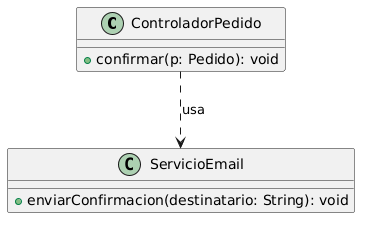

In [34]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class ControladorPedido {
  + confirmar(p: Pedido): void
}
class ServicioEmail {
  + enviarConfirmacion(destinatario: String): void
}
ControladorPedido ..> ServicioEmail : usa
@enduml'''

render_plantuml(plantuml_code)

En este ejemplo, `ControladorPedido` usa `ServicioEmail` probablemente dentro del método `confirmar`, pero no mantiene una referencia permanente a él; puede crearlo, llamarlo y descartarlo. La dependencia se satisface a nivel de método, no a nivel de instancia.

Para reforzar la diferencia entre dependencia y asociación, veamos un contraste directo:


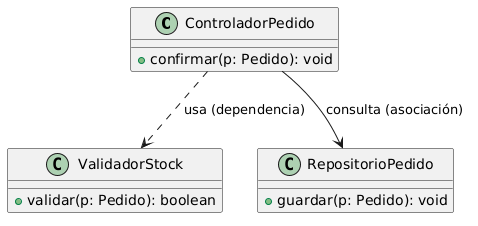

In [35]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class ControladorPedido {
  + confirmar(p: Pedido): void
}
class ValidadorStock {
  + validar(p: Pedido): boolean
}
class RepositorioPedido {
  + guardar(p: Pedido): void
}
ControladorPedido ..> ValidadorStock : usa (dependencia)
ControladorPedido --> RepositorioPedido : consulta (asociación)
@enduml'''

render_plantuml(plantuml_code)

`ControladorPedido` tiene una **dependencia** con `ValidadorStock` porque lo utiliza solo dentro del método `confirmar()` —posiblemente lo instancia o lo recibe como parámetro, lo llama y lo descarta. No guarda ninguna referencia a él como atributo. En cambio, `ControladorPedido` tiene una **asociación** con `RepositorioPedido`: mantiene una referencia permanente (un atributo) para poder invocar `guardar()` cada vez que necesita persistir un pedido.

En la práctica, una pista para distinguirlos: pregúntense si la clase A tiene un **atributo** del tipo B. Si la respuesta es sí, es asociación. Si solo aparece como variable local, parámetro o retorno, es dependencia.


## 3.6. Multiplicidad y navegabilidad: afinando las conexiones

Tanto las asociaciones como las agregaciones y composiciones pueden —y deben— precisarse con multiplicidad en cada extremo. La multiplicidad indica cuántas instancias de una clase se relacionan con cuántas de la otra. Los valores posibles incluyen números concretos (`1`, `2`), rangos (`0..1`, `3..5`), el asterisco (`*` significa cero o muchos) y combinaciones (`1..*`).

La navegabilidad, por su parte, indica en qué dirección es posible recorrer la asociación. Una flecha en el extremo de la línea señala que desde esa clase se puede acceder a la otra, pero no necesariamente al revés.


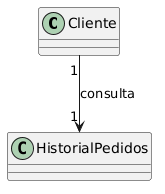

In [36]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente
class HistorialPedidos
Cliente "1" --> "1" HistorialPedidos : consulta
@enduml'''

render_plantuml(plantuml_code)

La flecha a la derecha de la línea indica que `Cliente` puede navegar hacia `HistorialPedidos`, pero no al revés a menos que se explicite.


## 3.7. Cómo elegir la relación correcta: una guía práctica

Frente a un caso de uso concreto, la elección de la relación adecuada surge de preguntarse:

- ¿A necesita una referencia permanente a B? → **Asociación**.
- ¿A está compuesto por B y B no puede vivir sin A? → **Composición**.
- ¿A está compuesto por B pero B puede existir por sí mismo? → **Agregación**.
- ¿A es un tipo más específico de B? → **Herencia**.
- ¿A se compromete a cumplir el contrato definido por B? → **Realización** (interfaz).
- ¿A usa a B solo de pasada, sin conservarla? → **Dependencia**.

## 3.8. Tabla resumen de relaciones UML y su correspondencia en PlantUML

| Relación | Símbolo UML | Sintaxis PlantUML | Cuándo usarla |
|----------|-------------|-------------------|---------------|
| Asociación | Línea continua | `A -- B` | Vínculo estructural permanente entre clases independientes |
| Asociación con navegabilidad | Flecha abierta | `A --> B` | Asociación recorrible solo en un sentido |
| Agregación | Rombo blanco | `A o-- B` | Relación todo-parte donde la parte sobrevive sin el todo |
| Composición | Rombo negro | `A *-- B` | Relación todo-parte donde la parte no existe sin el todo |
| Herencia | Triángulo hueco | `A <|-- B` o `A extends B` | Relación "es-un" |
| Realización | Triángulo hueco punteado | `A <|.. B` o `A implements B` | Una clase cumple el contrato de una interfaz |
| Dependencia | Flecha punteada | `A ..> B` | Uso temporal o puntual, sin referencia permanente |


## 3.9. Versatilidad de la notación PlantUML para todas las relaciones

PlantUML permite personalizar el estilo de las líneas con colores, grosores y patrones (punteado, discontinuo, etc.) usando las notaciones con corchetes `[#color,thickness=n]` o los estereotipos de línea `[bold]`, `[dashed]`, `[dotted]`, `[hidden]` y `[plain]`. Esto puede ser muy útil para diferenciar visualmente la criticidad de ciertas asociaciones.

También es posible controlar la **dirección de las flechas** en PlantUML para mejorar la legibilidad del diagrama. Por defecto, PlantUML usa el motor Graphviz para disponer las clases automáticamente, pero podemos sugerir direcciones con sufijos como `-down->`, `-up->`, `-left->` y `-right->`. Por ejemplo:


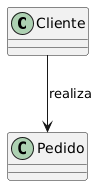

In [37]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cliente -down-> Pedido : realiza
@enduml'''

render_plantuml(plantuml_code)

### Actividades propuestas — Tema 3

1. **Identificar relaciones:** Dado el siguiente dominio: "Un hospital tiene múltiples departamentos. Cada departamento tiene varios médicos. Un médico puede atender a varios pacientes. Cada paciente tiene un historial médico que contiene varias entradas." Identifique qué tipo de relación corresponde a cada vínculo y escríbalo en PlantUML.
2. **Tabla resumen:** Sin mirar el documento, dibuje la tabla de relaciones UML (símbolo, nombre y cuándo usarla) y compárela con la sección 3.8.
3. **Roles y multiplicidad:** Modele la relación entre `Persona` y la clase `Persona` (autorreferencial) donde una persona puede ser mentor de otra. Use roles y multiplicidad.
4. **Dependencia vs. asociación:** Escriba un ejemplo PlantUML donde una clase `Informe` tenga una asociación con `BaseDatos` y una dependencia con `Impresora`. Explique la diferencia en un comentario (`'`) en el código.
5. **Ejercicio integrador:** Modele un sistema de biblioteca donde haya `Libro`, `Socio`, `Prestamo` y `Copia`. Decida qué relaciones aplicar entre ellas (asociación, agregación, composición, herencia) y justifique cada decisión.


# 4. Multiplicidad y navegabilidad: afinando las conexiones entre clases

Recuerdo una anécdota de mis primeros años como consultor: un equipo había diseñado un sistema de gestión de pedidos con un diagrama de clases impecable a primera vista. Cuando pregunté "¿cuántos pedidos puede tener un cliente?", me miraron con dudas. No lo habían especificado. El desarrollador asumió que solo uno, el analista de negocio asumió que muchos. El resultado fue un retraso de tres semanas para rehacer media base de datos. Desde entonces, tengo una regla que nunca rompo: toda asociación debe llevar multiplicidad en ambos extremos, o no está terminada.

Hemos construido el esqueleto de nuestro modelo estructural: tenemos clases, atributos, métodos y sabemos cómo relacionarlas mediante asociaciones, agregaciones, composiciones, herencias y dependencias. Pero ese esqueleto aún es tosco. Decir que un `Cliente` está asociado con un `Pedido` es un avance, pero no responde a preguntas cruciales para el desarrollador: ¿un cliente puede tener muchos pedidos o solo uno? ¿un pedido pertenece obligatoriamente a un cliente? ¿desde un pedido puedo obtener directamente el cliente que lo realizó, o solo desde el cliente puedo llegar a sus pedidos? La **multiplicidad** y la **navegabilidad** son las herramientas que UML nos proporciona para refinar esas conexiones hasta convertirlas en instrucciones precisas de diseño.


## 4.1. Multiplicidad: cuántos objetos participan en la relación

La multiplicidad (también llamada cardinalidad) especifica el número de instancias de una clase que pueden estar vinculadas a una instancia de la otra clase en una asociación determinada. Se indica en cada extremo de la línea de asociación.

Los valores de multiplicidad que permite UML son:

- `1` : exactamente uno.
- `0..1` : cero o uno (opcional).
- `0..*` o simplemente `*` : cero o muchos.
- `1..*` : al menos uno, puede ser muchos.
- `n` : un número fijo (por ejemplo, `2` para los dos titulares de una cuenta mancomunada).
- `n..m` : un rango concreto (por ejemplo, `3..5`).

Veamos un ejemplo aplicado a nuestro dominio de comercio electrónico:


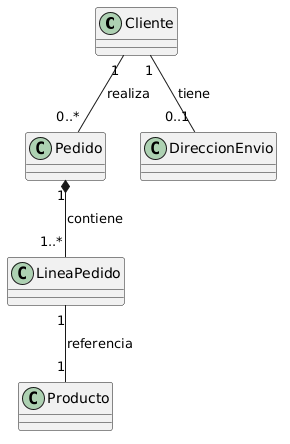

In [38]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente
class Pedido
class Producto
class LineaPedido
class DireccionEnvio

Cliente "1" -- "0..*" Pedido : realiza
Pedido "1" *-- "1..*" LineaPedido : contiene
LineaPedido "1" -- "1" Producto : referencia
Cliente "1" -- "0..1" DireccionEnvio : tiene
@enduml'''

render_plantuml(plantuml_code)

Interpretemos cada multiplicidad:

- `Cliente "1" -- "0..*" Pedido` : un pedido pertenece exactamente a un cliente; un cliente puede tener cero o más pedidos.
- `Pedido "1" *-- "1..*" LineaPedido` : una línea de pedido pertenece exactamente a un pedido (composición); un pedido debe tener al menos una línea y puede tener muchas.
- `LineaPedido "1" -- "1" Producto` : una línea de pedido referencia exactamente un producto.
- `Cliente "1" -- "0..1" DireccionEnvio` : un cliente puede tener una dirección de envío por defecto, o ninguna.

La multiplicidad no es un adorno: define restricciones que el sistema debe hacer cumplir. Si indicamos que un `Pedido` debe tener al menos una `LineaPedido`, el código deberá impedir la creación de pedidos vacíos.


## 4.2. Cómo derivar la multiplicidad desde los casos de uso

Los casos de uso nos dan pistas valiosas sobre las multiplicidades. Frases como "el cliente puede consultar todos sus pedidos" sugieren que un cliente puede tener múltiples pedidos (multiplicidad `0..*`). "Cada pedido incluye al menos un producto" sugiere `1..*` en el extremo de `LineaPedido`. "Un cliente puede guardar una dirección de envío preferida" apunta a `0..1`.

Las postcondiciones también ayudan. Si al finalizar "Realizar Pedido" se indica que "el pedido queda registrado con un cliente asociado", confirmamos que la asociación `Cliente-Pedido` tiene multiplicidad `1` en el extremo del cliente.


## 4.3. Navegabilidad: la dirección del conocimiento

Si la multiplicidad responde a "¿cuántos?", la navegabilidad responde a "¿quién conoce a quién?". En una asociación entre dos clases, podemos decidir que el vínculo sea recorrible en un solo sentido, en ambos, o en ninguno. La navegabilidad se representa con una punta de flecha en el extremo de la línea, apuntando hacia la clase que "es conocida".

En PlantUML, la navegabilidad se indica añadiendo `>` o `<` en la definición de la línea. Así, `ClaseA --> ClaseB` dibuja una flecha desde A hacia B, significando que desde A se puede acceder a B, pero no necesariamente al revés. Si se desea navegabilidad bidireccional, se omite la punta de flecha (solo `--`).


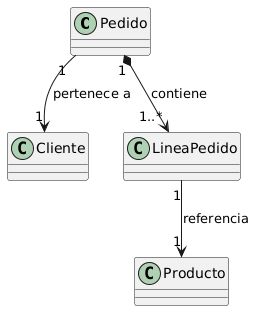

In [39]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Pedido
class Cliente
class LineaPedido
class Producto

Pedido "1" --> "1" Cliente : pertenece a
Pedido "1" *--> "1..*" LineaPedido : contiene
LineaPedido "1" --> "1" Producto : referencia
@enduml'''

render_plantuml(plantuml_code)

En este modelo, desde un `Pedido` puedo navegar hacia su `Cliente` (la flecha apunta a `Cliente`), pero no al revés: un `Cliente` no tiene una referencia directa a sus pedidos; si necesito obtener los pedidos de un cliente, tendré que buscarlos mediante una consulta. Esto es una decisión de diseño: desacoplamos `Cliente` de `Pedido` para que `Cliente` no acumule una colección potencialmente enorme.

Si quisiéramos navegabilidad bidireccional entre `Pedido` y `Cliente`, omitiríamos la flecha:


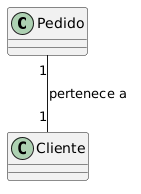

In [40]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Pedido
class Cliente
Pedido "1" -- "1" Cliente : pertenece a
@enduml'''

render_plantuml(plantuml_code)

## 4.4. Derivación de la navegabilidad desde los casos de uso

El caso de uso nos permite responder a la pregunta: en un paso dado, ¿qué objeto necesita acceder a cuál? En "Realizar Pedido", cuando el sistema debe "mostrar el historial de pedidos de un cliente", necesitamos navegar desde `Cliente` a `Pedido`; eso sugiere navegabilidad de `Cliente` hacia `Pedido`. Pero si más adelante otro caso de uso requiere que, dado un pedido, se localice al cliente para enviarle una notificación, entonces necesitamos navegabilidad inversa.

## 4.5. Combinando multiplicidad y navegabilidad

Ambos conceptos se combinan en la misma notación. La multiplicidad se coloca junto al extremo de la clase, la navegabilidad se deduce de la punta de flecha.


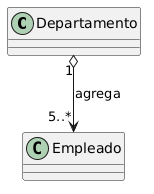

In [41]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Departamento
class Empleado
Departamento "1" o--> "5..*" Empleado : agrega
@enduml'''

render_plantuml(plantuml_code)

Aquí, un `Departamento` agrega de cinco a muchos `Empleado`s (agregación), y desde `Departamento` se puede navegar hacia sus empleados (flecha), pero no al revés. Un empleado no conoce directamente su departamento.

Otro ejemplo con navegabilidad bidireccional:


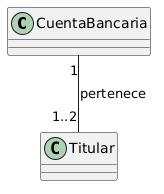

In [42]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class CuentaBancaria
class Titular
CuentaBancaria "1" -- "1..2" Titular : pertenece
@enduml'''

render_plantuml(plantuml_code)

## 4.6. Buenas prácticas en multiplicidad y navegabilidad

- **No sobrecargar de flechas**: si todas las asociaciones son bidireccionales, el diagrama puede volverse confuso.
- **La multiplicidad debe reflejar las reglas de negocio**: antes de escribir `0..*` o `1..*`, pregúntense qué permite el negocio.
- **Revisar las multiplicidades con los stakeholders**: un analista de negocio puede confirmar si realmente un cliente puede tener un número ilimitado de pedidos o si hay un límite.
- **Actualizar el modelo con cada nuevo caso de uso**: un nuevo caso de uso puede requerir navegabilidad inversa o modificar una multiplicidad.

## 4.7. Representación en PlantUML: detalles avanzados

La guía de PlantUML ofrece variantes para personalizar la visualización de las relaciones, incluyendo líneas de estilo `[bold]`, `[dashed]`, `[dotted]`, colores y grosores.


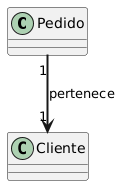

In [43]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Pedido
class Cliente
Pedido "1" -[bold]-> "1" Cliente : pertenece
@enduml'''

render_plantuml(plantuml_code)

## 4.8. Más allá del diagrama: impacto en la implementación

La multiplicidad y la navegabilidad tienen consecuencias directas en el código. Si entre `Pedido` y `LineaPedido` definimos composición con multiplicidad `1..*` y navegabilidad unidireccional desde `Pedido`, el código resultante tendrá en `Pedido` una colección de `LineaPedido` que se inicializa en el constructor, y posiblemente métodos `agregarLinea` y `eliminarLinea`. No existirá una referencia inversa desde `LineaPedido` a `Pedido`.

### Actividades propuestas — Tema 4

1. **Determinar multiplicidades:** Para la relación entre `Avión` y `Vuelo`, determine las multiplicidades sabiendo que: un avión puede tener muchos vuelos a lo largo de su vida, pero cada vuelo usa exactamente un avión. Un vuelo puede tener varios pilotos asignados, y un piloto puede volar en muchos vuelos. Modele en PlantUML.
2. **Navegabilidad:** Dado el modelo `Escuela "1" --> "*" Estudiante : matricula` y `Estudiante "1" --> "*" Curso : inscrito`, ¿qué navegabilidades elegiría y por qué? ¿Cambiaría alguna a bidireccional? Justifique su respuesta.
3. **Caso práctico:** Modele en PlantUML la relación entre `Proyecto`, `Tarea` y `Empleado` considerando: un proyecto tiene muchas tareas, una tarea es asignada a un empleado, un empleado puede estar en varios proyectos. Decida multiplicidades, navegabilidad y tipo de relación.
4. **Análisis de impacto:** Tome el modelo de comercio electrónico de esta sección y modifique la multiplicidad de `Cliente -- Pedido` de `0..*` a `1..5`. ¿Qué implicaciones tiene en el código y en la interfaz de usuario?


# 5. Del caso de uso al diagrama de clases: identificando clases a partir del análisis funcional

De todas las habilidades que he tenido que enseñar a lo largo de mi carrera —y he enseñado a cientos de ingenieros—, esta es, sin duda, la que marca la diferencia entre un analista mediocre y uno excelente. Cualquiera puede dibujar un diagrama de clases bonito. Pero saber *de dónde vienen* cada clase, cada atributo y cada relación, y poder justificarlos ante un cliente o un desarrollador, eso es lo que convierte a un ingeniero en un profesional completo.

Hemos consolidado ya los pilares del modelado: sabemos capturar las funcionalidades del sistema mediante casos de uso y conocemos la sintaxis y la semántica de los diagramas de clases, incluyendo las multiplicidades y navegabilidades que acabamos de estudiar. Ahora ha llegado el momento de tender el puente entre ambas vistas. Este es, desde mi experiencia, el proceso intelectual más determinante en la fase de análisis y diseño: **derivar el modelo estructural del sistema a partir de las necesidades funcionales expresadas en los casos de uso**.


## 5.1. La esencia del método: escuchar al caso de uso

Cuando enseño esta técnica, siempre pongo la misma analogía: leer un caso de uso para extraer clases es como leer una novela policíaca para encontrar pistas. El autor no te dice directamente quién es el culpable; tienes que leer entre líneas, identificar los personajes recurrentes, las acciones significativas y las relaciones entre ellos.

La especificación textual de un caso de uso describe, en lenguaje natural, una secuencia de interacciones entre actores y sistema. Si leemos con atención, encontraremos tres categorías lingüísticas que nos orientan:

- **Sustantivos**: suelen corresponder a clases o atributos.
- **Verbos**: suelen corresponder a métodos.
- **Frases posesivas o de pertenencia** ("el pedido del cliente", "las líneas del pedido"): sugieren relaciones estructurales entre clases.


## 5.2. Identificación de clases candidatas a partir de los sustantivos

El primer paso consiste en extraer todos los sustantivos y sintagmas nominales que aparecen en los flujos del caso de uso. No todos se convertirán en clases; algunos serán atributos de otras clases, otros serán actores externos y otros serán conceptos irrelevantes.

Del fragmento de "Realizar Pedido" obtenemos:

| Sustantivo | Posible significado en el modelo |
|------------|----------------------------------|
| Cliente | Actor o clase |
| Pedido | Candidato a clase (entidad central) |
| Catálogo | Candidato a clase |
| Producto | Candidato a clase |
| Cantidad | Atributo |
| Carrito | Candidato a clase |
| Pago | Candidato a clase |
| Inventario | Candidato a clase |
| Correo | Atributo o clase |

## 5.3. Identificación de atributos

Una vez tenemos las clases candidatas, las enriquecemos buscando en el caso de uso los datos que se mencionan explícitamente. En el flujo de "Realizar Pedido" aparecen: "cantidad", "dirección de envío", "precio", "total", "fecha del pedido", "email del cliente", "estado del pedido".

Por ejemplo, `Pedido` tendrá atributos como `fechaPedido: Date`, `total: double`, `estado: String`, `direccionEnvio: String`.

## 5.4. Identificación de métodos

Los verbos de acción del caso de uso se convierten en métodos de las clases adecuadas. Asignar un método a la clase correcta es una decisión de diseño que debe basarse en el principio de **experto en información**: el método debe residir en la clase que posee los datos necesarios para llevarlo a cabo.

- "El Sistema muestra el catálogo" → `Catalogo.mostrarProductosDisponibles()`
- "El Sistema agrega los productos al carrito" → `Carrito.agregarProducto()`
- "El Sistema calcula el total" → `Pedido.calcularTotal()`
- "El Sistema procesa el pago" → `Pago.procesar()`
- "El Sistema envía un correo de confirmación" → `ServicioCorreo.enviarConfirmacion()`

## 5.5. Identificación de relaciones

Con las clases, atributos y métodos sobre la mesa, el siguiente paso es conectarlas mediante las relaciones adecuadas. Recurrimos de nuevo al caso de uso: las frases que indican posesión, pertenencia o colaboración nos guían.

- "El pedido del cliente" → asociación entre `Cliente` y `Pedido`
- "El pedido contiene líneas de pedido" → composición entre `Pedido` y `LineaPedido`
- "Cada línea de pedido referencia un producto" → asociación entre `LineaPedido` y `Producto`
- "El pago está asociado a un pedido" → asociación uno a uno entre `Pedido` y `Pago`


## 5.6. Trazabilidad explícita: tabla de derivación caso de uso → modelo

Para que el proceso de derivación sea verdaderamente sistemático, conviene documentar explícitamente la trazabilidad entre los elementos del caso de uso y los del diagrama de clases:

| Paso del caso de uso | Sustantivo → Clase/Atributo | Verbo → Método | Frase preposicional → Relación |
|----------------------|----------------------------|----------------|-------------------------------|
| 1. El Cliente solicita iniciar un nuevo pedido | `Cliente`, `Pedido` | `solicitar()` → `Pedido.crear()` | "del Cliente" → `Cliente -- Pedido` |
| 2. El Sistema muestra el catálogo | `Catalogo`, `Producto` | `mostrar()` → `Catalogo.mostrarProductos()` | – |
| 3. El Cliente selecciona productos y cantidades | `cantidad` (atributo de `LineaPedido`) | `seleccionar()` → `Carrito.agregarProducto()` | – |
| 4. El Sistema agrega productos al carrito | `Carrito` | `agregar()` → `Carrito.agregarProducto()` | "al carrito" → `Carrito o-- Producto` |
| 5. El Sistema calcula el total | `total` (atributo de `Pedido`) | `calcular()` → `Pedido.calcularTotal()` | – |
| 6. El Sistema procesa el pago | `Pago` | `procesar()` → `Pago.procesar()` | "asociado a" → `Pedido -- Pago` |
| 7. El Sistema actualiza el inventario | `stock` (atributo de `Producto`) | `actualizar()` → `Producto.decrementarStock()` | – |
| 8. El Sistema envía correo de confirmación | `ServicioCorreo` | `enviar()` → `ServicioCorreo.enviarConfirmacion()` | – |

Esta tabla no solo documenta el proceso, sino que permite validar que cada elemento del modelo tiene una justificación funcional.


## 5.7. Refinamiento iterativo: del modelo inicial al detallado

El modelo de clases no surge completo en una sola pasada. Una estrategia muy efectiva es empezar con un **modelo inicial** que contenga solo los nombres de las clases, y luego **refinarlo iterativamente** añadiendo atributos, métodos y relaciones.

**Paso 1 — Modelo inicial (solo clases):**


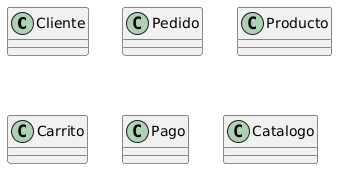

In [44]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente
class Pedido
class Producto
class Carrito
class Pago
class Catalogo
@enduml'''

render_plantuml(plantuml_code)

**Paso 2 — Añadir relaciones tras revisar el flujo básico:**


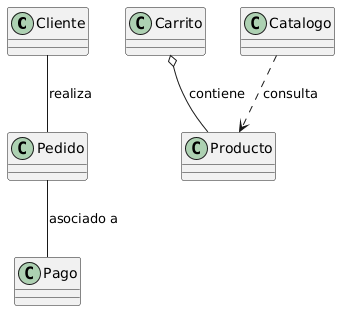

In [45]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente
class Pedido
class Producto
class Carrito
class Pago
class Catalogo

Cliente -- Pedido : realiza
Pedido -- Pago : asociado a
Carrito o-- Producto : contiene
Catalogo ..> Producto : consulta
@enduml'''

render_plantuml(plantuml_code)

**Paso 3 — Refinar con multiplicidades, atributos y métodos al revisar flujos alternativos:**


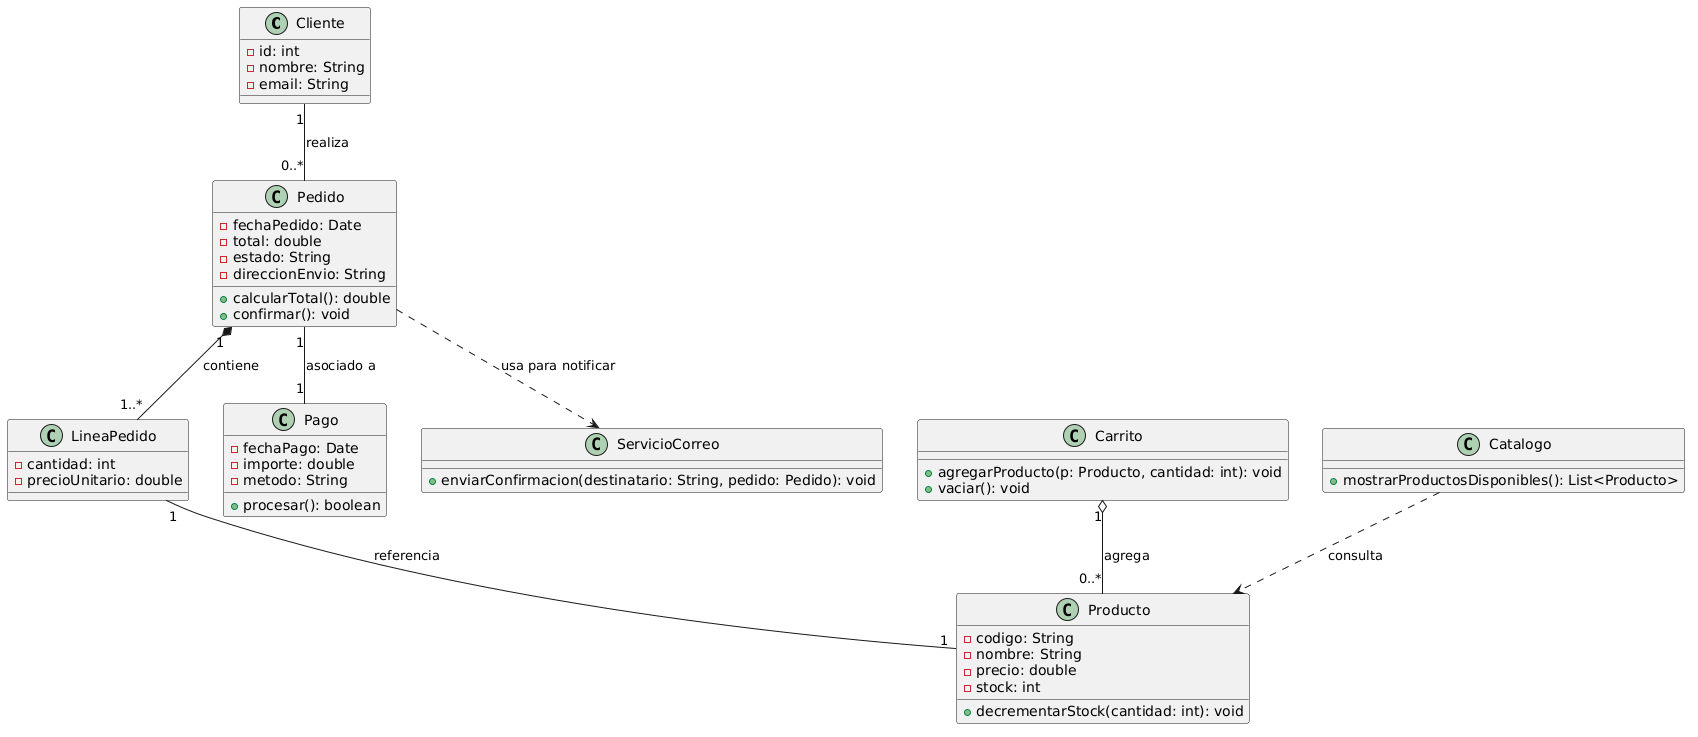

In [46]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Cliente {
  - id: int
  - nombre: String
  - email: String
}

class Pedido {
  - fechaPedido: Date
  - total: double
  - estado: String
  - direccionEnvio: String
  + calcularTotal(): double
  + confirmar(): void
}

class LineaPedido {
  - cantidad: int
  - precioUnitario: double
}

class Producto {
  - codigo: String
  - nombre: String
  - precio: double
  - stock: int
  + decrementarStock(cantidad: int): void
}

class Carrito {
  + agregarProducto(p: Producto, cantidad: int): void
  + vaciar(): void
}

class Pago {
  - fechaPago: Date
  - importe: double
  - metodo: String
  + procesar(): boolean
}

class ServicioCorreo {
  + enviarConfirmacion(destinatario: String, pedido: Pedido): void
}

class Catalogo {
  + mostrarProductosDisponibles(): List<Producto>
}

' Relaciones
Cliente "1" -- "0..*" Pedido : realiza
Pedido "1" *-- "1..*" LineaPedido : contiene
LineaPedido "1" -- "1" Producto : referencia
Pedido "1" -- "1" Pago : asociado a
Carrito "1" o-- "0..*" Producto : agrega
Pedido ..> ServicioCorreo : usa para notificar
Catalogo ..> Producto : consulta
@enduml'''

render_plantuml(plantuml_code)

## 5.8. Refinamiento con estereotipos

Dependiendo de la metodología que empleemos, podemos añadir estereotipos como `<<entity>>`, `<<boundary>>` o `<<control>>` para clarificar el rol de cada clase.


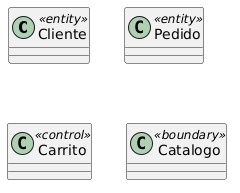

In [47]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class "Cliente" <<entity>>
class "Pedido" <<entity>>
class "Carrito" <<control>>
class "Catalogo" <<boundary>>
@enduml'''

render_plantuml(plantuml_code)

## 5.9. Iteración y validación con los casos de uso

El modelo de clases no se termina en la primera pasada. Al revisar otros casos de uso del sistema, el modelo se enriquece. Por ejemplo, si existiese un caso de uso "Consultar Historial de Pedidos", añadiríamos probablemente un método `obtenerPedidosPorCliente()` en la clase `Cliente` o en un controlador.

Cada nuevo caso de uso puede hacer crecer atributos y métodos, o incluso revelar la necesidad de nuevas clases. La clave es mantener la trazabilidad: si una clase o método no puede vincularse a ningún caso de uso, probablemente sea innecesaria.

## 5.10. Errores frecuentes en la derivación

- **Clases que deberían ser atributos**: a veces "Dirección de envío" no necesita su propia clase si solo se almacena como texto.
- **Métodos huérfanos**: asignar un método a una clase que no tiene los datos para ejecutarlo.
- **Composición donde basta asociación**: recordar que la composición implica destrucción en cascada.
- **Olvidar las restricciones de multiplicidad**: omitir la multiplicidad conduce a ambigüedades.

### Actividades propuestas — Tema 5

1. **Tabla de trazabilidad:** Tome el siguiente fragmento de caso de uso: "El usuario selecciona productos del catálogo, el sistema calcula el total con impuestos, aplica el descuento si es cliente VIP y genera la factura." Cree una tabla de trazabilidad como la de la sección 5.6 identificando clases, atributos, métodos y relaciones candidatos.
2. **Refinamiento iterativo:** Partiendo de las clases `Usuario`, `Producto` y `Factura`, añada progresivamente atributos, métodos y relaciones. Muestre tres versiones: inicial (solo clases), intermedia (con relaciones), final (con detalles completos).
3. **Derivación completa:** Dado el caso de uso "Gestionar reservas de un hotel" (el cliente busca habitaciones disponibles, selecciona fechas, confirma la reserva, el sistema registra el pago y envía confirmación), derive el diagrama de clases completo en PlantUML.
4. **Validación cruzada:** Intercambie su diagrama de clases con un compañero. Cada uno debe identificar qué clases, atributos y métodos no tienen trazabilidad con ningún caso de uso y proponer su eliminación o justificación.


# 6. Clases abstractas, interfaces y paquetes: elevando la abstracción del modelo

Cuando empecé a enseñar modelado, mis alumnos solían preguntarme: "¿Y cuándo usamos todo esto en proyectos reales?" Mi respuesta siempre era la misma: cuando el sistema tiene más de veinte clases. Hasta ese momento, un modelo plano funciona. Pero en el mundo profesional, los sistemas tienen cientos o miles de clases, y ahí es donde los mecanismos de abstracción marcan la diferencia entre un modelo que ayuda y un modelo que abruma.

UML, y por tanto PlantUML, nos proporcionan tres mecanismos para manejar esta complejidad: las **clases abstractas**, las **interfaces** y los **paquetes**.


## 6.1. Clases abstractas: el molde que no se instancia

Una clase abstracta es una clase que **no puede ser instanciada directamente**. Su propósito es servir como plantilla para otras clases (sus subclases), proporcionándoles una estructura común de atributos y métodos, algunos de los cuales pueden estar implementados y otros no.

En UML, una clase abstracta se distingue visualmente porque su nombre y, a menudo, sus métodos abstractos, aparecen en **cursiva**. PlantUML sigue esta convención.

¿Cuándo usar una clase abstracta? Cuando tenemos un conjunto de clases que comparten una parte significativa de implementación, pero también requieren que cada una personalice ciertos comportamientos.


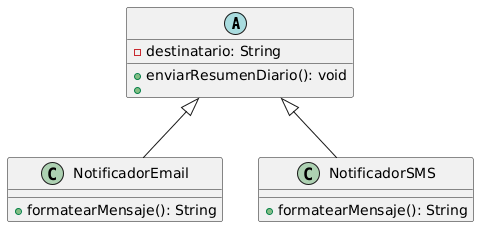

In [48]:
# Diagrama PlantUML
plantuml_code = '''@startuml
abstract class Notificador {
  - destinatario: String
  + enviarResumenDiario(): void
  {abstract} + formatearMensaje(): String
}

class NotificadorEmail extends Notificador {
  + formatearMensaje(): String
}

class NotificadorSMS extends Notificador {
  + formatearMensaje(): String
}
@enduml'''

render_plantuml(plantuml_code)

En este ejemplo, `Notificador` es abstracta y declara un método abstracto `formatearMensaje()`. Las subclases heredan el atributo `destinatario` y el método `enviarResumenDiario()` ya implementado, pero deben proporcionar su propia versión de `formatearMensaje()`.

La guía de PlantUML también permite usar la palabra reservada `abstract` antes del nombre de la clase:


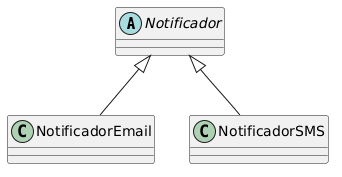

In [49]:
# Diagrama PlantUML
plantuml_code = '''@startuml
abstract class Notificador
class NotificadorEmail extends Notificador
class NotificadorSMS extends Notificador
@enduml'''

render_plantuml(plantuml_code)

## 6.2. Interfaces: el contrato puro

Si una clase abstracta es un molde que puede contener implementación, una interfaz es un **contrato puro**: no proporciona ninguna implementación, solo declara un conjunto de métodos que las clases que la realicen deben implementar obligatoriamente.

¿Cuándo usar una interfaz en lugar de una clase abstracta? Si lo que queremos es compartir implementación, usamos clase abstracta. Si lo que queremos es definir un comportamiento que múltiples clases no relacionadas jerárquicamente deben cumplir, usamos interfaz.

Un ejemplo clásico es la interfaz `IPagable` en un sistema de facturación:


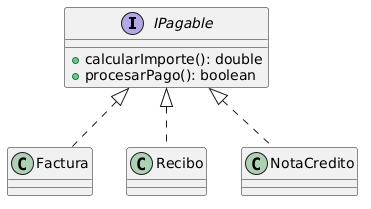

In [50]:
# Diagrama PlantUML
plantuml_code = '''@startuml
interface IPagable {
  + calcularImporte(): double
  + procesarPago(): boolean
}

class Factura implements IPagable
class Recibo implements IPagable
class NotaCredito implements IPagable
@enduml'''

render_plantuml(plantuml_code)

La notación de "lollipop" es especialmente útil cuando queremos mostrar la interfaz de forma compacta:


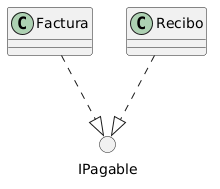

In [51]:
# Diagrama PlantUML
plantuml_code = '''@startuml
() IPagable
class Factura
class Recibo
Factura ..|> IPagable
Recibo ..|> IPagable
@enduml'''

render_plantuml(plantuml_code)

## 6.3. Clases abstractas versus interfaces: una decisión de diseño

| Criterio | Clase abstracta | Interfaz |
|----------|-----------------|----------|
| Proporciona implementación | Sí (parcial o total) | No (solo firmas) |
| Herencia múltiple | No (una sola clase padre) | Sí (múltiples interfaces) |
| Constructor | Sí | No |
| Atributos | Sí | No (solo constantes estáticas) |
| Relación semántica | "es-un" (herencia) | "se comporta como" (contrato) |

En la práctica, muchos diseños modernos tienden a preferir interfaces combinadas con composición, reservando las clases abstractas para situaciones donde realmente haya una implementación común.


## 6.4. Paquetes: organizando el modelo de clases

Si las clases abstractas y las interfaces gestionan la complejidad dentro del modelo, los paquetes la gestionan desde fuera, agrupando clases relacionadas en módulos con significado propio.

Los paquetes son esenciales cuando el sistema alcanza unas pocas decenas de clases. Con paquetes, podemos dividir el modelo en subsistemas lógicos: "Dominio", "Persistencia", "Servicios", "Interfaz de Usuario", etc.

En PlantUML, los paquetes se declaran con la palabra reservada `package`, y su contenido se delimita con llaves `{}`.


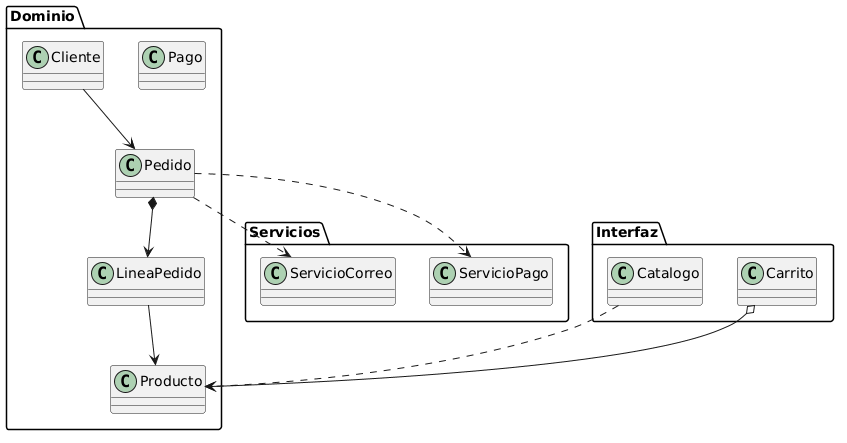

In [52]:
# Diagrama PlantUML
plantuml_code = '''@startuml
package "Dominio" {
  class Cliente
  class Pedido
  class LineaPedido
  class Producto
  class Pago
}

package "Servicios" {
  class ServicioCorreo
  class ServicioPago
}

package "Interfaz" {
  class Catalogo
  class Carrito
}

Cliente --> Pedido
Pedido *--> LineaPedido
LineaPedido --> Producto
Pedido ..> ServicioCorreo
Pedido ..> ServicioPago
Catalogo ..> Producto
Carrito o--> Producto
@enduml'''

render_plantuml(plantuml_code)

Los paquetes pueden relacionarse entre sí mediante dependencias (`..>`), indicando que un paquete necesita elementos de otro:


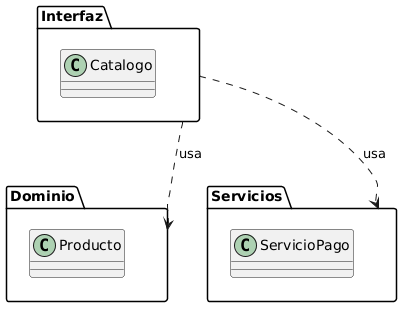

In [53]:
# Diagrama PlantUML
plantuml_code = '''@startuml
package "Interfaz" {
  class Catalogo
}
package "Dominio" {
  class Producto
}
package "Servicios" {
  class ServicioPago
}

Interfaz ..> Dominio : usa
Interfaz ..> Servicios : usa
@enduml'''

render_plantuml(plantuml_code)

### 6.4.1. Organización en capas con paquetes anidados

En proyectos reales, los paquetes suelen reflejar una **arquitectura en capas**. La organización más habitual divide el sistema en cuatro capas:

1. **Presentación (Interfaz):** controladores, vistas, DTOs.
2. **Aplicación:** servicios de aplicación, casos de uso orquestados.
3. **Dominio:** entidades, objetos de valor, repositorios (interfaces).
4. **Infraestructura:** repositorios (implementaciones), acceso a datos, servicios externos.


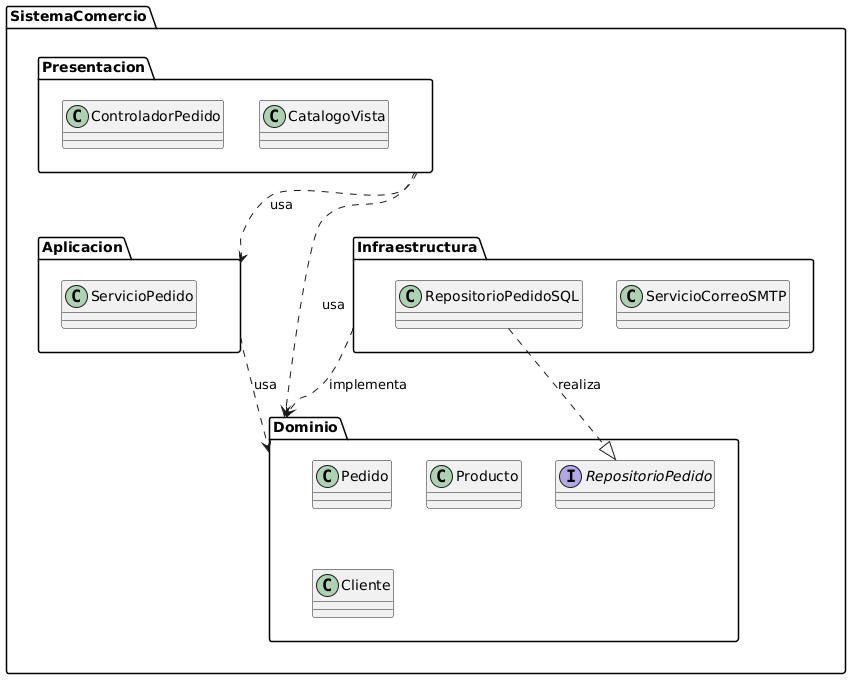

In [54]:
# Diagrama PlantUML
plantuml_code = '''@startuml
package "SistemaComercio" {
  package "Presentacion" {
    class ControladorPedido
    class CatalogoVista
  }
  package "Aplicacion" {
    class ServicioPedido
  }
  package "Dominio" {
    class Pedido
    class Producto
    class Cliente
    interface RepositorioPedido
  }
  package "Infraestructura" {
    class RepositorioPedidoSQL
    class ServicioCorreoSMTP
  }
}

' Dependencias entre capas
Presentacion ..> Aplicacion : usa
Presentacion ..> Dominio : usa
Aplicacion ..> Dominio : usa
Infraestructura ..> Dominio : implementa
RepositorioPedidoSQL ..|> RepositorioPedido : realiza
@enduml'''

render_plantuml(plantuml_code)

## 6.5. Cómo se derivan estos elementos desde los casos de uso

Las clases abstractas y las interfaces no suelen aparecer directamente en la especificación textual, sino que surgen durante el diseño como abstracciones que unifican conceptos dispersos. Si en varios casos de uso aparece la necesidad de pagar de diferentes formas, deducimos una interfaz `MetodoPago`. Si varias clases comparten atributos y métodos idénticos, extraemos una clase abstracta.

Los paquetes, por su parte, se corresponden a menudo con las agrupaciones funcionales que ya identificamos en los diagramas de casos de uso.

### Actividades propuestas — Tema 6

1. **Interfaz vs. clase abstracta:** Diseñe un modelo para un sistema de notificaciones donde existan `NotificacionEmail`, `NotificacionSMS` y `NotificacionPush`. Decida si usa una interfaz o una clase abstracta y justifique. Modele en PlantUML.
2. **Paquetes en capas:** Organice las clases del tema 5 (`Cliente`, `Pedido`, `LineaPedido`, `Producto`, `Pago`, `ServicioCorreo`, `ServicioPago`, `Catalogo`, `Carrito`) en una arquitectura de cuatro capas (Presentación, Aplicación, Dominio, Infraestructura) usando paquetes anidados de PlantUML. Añada las dependencias entre capas.
3. **Extensión del modelo:** Añada una interfaz `MetodoPago` realizada por `PagoTarjeta`, `PagoPayPal` y `PagoTransferencia` al modelo de comercio electrónico del tema 5. Integre las nuevas clases respetando la organización en paquetes.
4. **Reflexión crítica:** ¿Qué ventajas y desventajas tiene usar una interfaz frente a una clase abstracta en el sistema de notificaciones del ejercicio 1? Escriba su respuesta en una celda markdown.


# 7. Buenas prácticas y cierre: el arte de mantener vivo el modelo estructural

Permítanme serles sincero: he visto más diagramas de clases abandonados que diagramas vivos. En mis años de consultoría, he entrado a proyectos donde el diagrama de clases era un archivo PDF amarillento que nadie había tocado en dos años, mientras el código había evolucionado por completo. Eso no debería pasar. Y la buena noticia es que no tiene que pasar. Un diagrama de clases bien mantenido es uno de los activos más valiosos que un equipo de desarrollo puede tener.

Hemos recorrido un camino exhaustivo por el modelado estructural con UML y PlantUML. Ahora, antes de poner punto final a este bloque, es imprescindible consolidar una serie de buenas prácticas que aseguren que el diagrama de clases no se convierta en un adorno que se abandona tras la primera iteración, sino en un artefacto vivo, útil y respetado por todo el equipo.


## 7.1. Mantener el foco en el objetivo del modelo

Antes de dibujar una sola línea, debemos preguntarnos: ¿para quién es este diagrama y qué decisión debe informar? No es lo mismo un diagrama de clases de **análisis** —orientado a comunicar el dominio del problema a los expertos de negocio— que un diagrama de clases de **diseño** —orientado a guiar la implementación—. Y ambos son distintos de un diagrama de clases de **arquitectura**, que muestra solo los paquetes principales y sus dependencias.

## 7.2. Notación clara y consistente

La notación UML es un lenguaje, y como todo lenguaje, tiene dialectos y variantes. Para que el equipo se comunique sin ruido, es crucial establecer convenciones y respetarlas:

- **Nombres de clases**: singular, en CamelCase (p. ej., `LineaPedido`).
- **Nombres de atributos y métodos**: en camelCase, comenzando con minúscula (p. ej., `calcularTotal()`).
- **Visibilidad**: decidir si se mostrarán los iconos de visibilidad o se ocultarán.
- **Multiplicidades**: colocarlas siempre en ambos extremos de la asociación.
- **Uso de estereotipos**: limitado a los que realmente aportan información.

## 7.3. Derivar, no inventar: la trazabilidad con los casos de uso

Todo elemento del diagrama de clases —clase, atributo, método, relación— debe poder rastrearse hasta uno o varios casos de uso. Esta trazabilidad:

- Justifica la existencia de cada clase frente a los stakeholders.
- Facilita la estimación de impacto cuando un caso de uso cambia.
- Evita la proliferación de clases "por si acaso" que nunca se implementan.

## 7.4. La granularidad adecuada

Un diagrama de clases debe contener las clases necesarias para transmitir la idea central, y nada más. Como regla general, un diagrama de clases debería caber en una pantalla o en una página impresa. Si necesitamos más de 20 o 30 clases, usamos **paquetes** para crear vistas de más alto nivel.


## 7.5. Organización en paquetes significativa

La organización en paquetes no debe ser arbitraria. Los paquetes deben reflejar la cohesión lógica del dominio o, en su defecto, una arquitectura en capas bien definida.

- **Paquete por módulo funcional**: "Ventas", "Compras", "Almacén", "Facturación".
- **Paquete por capa técnica**: "Interfaz", "Aplicación", "Dominio", "Infraestructura".
- **Evitar paquetes "Miscelánea" o "Utilidades"**: son un imán para clases sin hogar.

## 7.6. Autodisciplina en el uso de relaciones

- **Asociación solo si hay vínculo estructural permanente**.
- **Composición solo si la parte no puede vivir sin el todo**.
- **Herencia solo si existe relación "es-un" genuina**.
- **Interfaces para contratos, no para simular herencia múltiple sin criterio**.

## 7.7. Mantenimiento continuo y versionado

El diagrama de clases es un artefacto de software más, y como tal, debe someterse a control de versiones y actualizarse con cada cambio significativo.

- **Almacenar los archivos `.puml` en el mismo repositorio que el código fuente**.
- **Revisar el diagrama en las reuniones de diseño**.
- **Usar `!include` para modularizar**: dividir el modelo en varios archivos.


## 7.8. Aprovechar las capacidades de PlantUML para la legibilidad

La guía de PlantUML nos brinda herramientas que, bien empleadas, mejoran sustancialmente la presentación:

- **Separadores y títulos dentro de clases**: usar para agrupar atributos y métodos lógicamente.
- **Notas y comentarios como parte del modelo vivo**: las notas no son simples adornos; son el lugar natural para documentar decisiones de diseño.


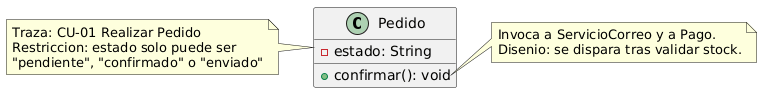

In [55]:
# Diagrama PlantUML
plantuml_code = '''@startuml
class Pedido {
  - estado: String
  + confirmar(): void
}
note left of Pedido
  Traza: CU-01 Realizar Pedido
  Restriccion: estado solo puede ser
  "pendiente", "confirmado" o "enviado"
end note

note right of Pedido::confirmar()
  Invoca a ServicioCorreo y a Pago.
  Disenio: se dispara tras validar stock.
end note
@enduml'''

render_plantuml(plantuml_code)

Las notas también pueden documentar el **porqué** de una decisión de diseño, no solo el **qué**. Por ejemplo, explicar por qué se eligió agregación en lugar de composición, o por qué una clase tiene cierta multiplicidad.

- **Estilos globales**: definir un estilo base con `skinparam` y aplicarlo consistentemente.
- **Dirección del diagrama**: `left to right direction` o `top to bottom direction` según convenga.

## 7.9. Errores frecuentes al mantener diagramas de clases

- **Diagrama desconectado de la realidad**: las clases no coinciden con el código.
- **Sobrecarga de detalles de implementación**: incluir clases de infraestructura, DTOs, etc.
- **Asociaciones sin nombres ni multiplicidad**.
- **Uso incorrecto de la composición**.
- **Atributos modelados como clases**.
- **Circularidad en las dependencias entre paquetes**.


## 7.10. Reflexión final: el diagrama de clases como lenguaje común

Llegamos al final de este bloque sobre modelado estructural. Durante más de veinte años he visto tecnologías ir y venir: lenguajes que prometían revolucionar el desarrollo, frameworks que quedaron obsoletos en dos años, metodologías que pasaron de moda. Pero el diagrama de clases sigue ahí. ¿Por qué? Porque no es una tecnología: es una forma de pensar. Es la manera en que los ingenieros de software organizamos mentalmente la complejidad antes de escribir una sola línea de código.

Hemos construido, paso a paso, la capacidad de plasmar la anatomía de un sistema software en un diagrama preciso, mantenible y comunicativo. Pero no quiero que se vayan con la idea de que el diagrama de clases es un fin en sí mismo. Es una herramienta, un lenguaje que permite a los ingenieros de software debatir, acordar y documentar la arquitectura interna de un sistema.

Les animo a que practiquen. Tomen los casos de uso que modelaron en el bloque anterior. Deriven sus clases. Discutan con sus compañeros si una relación es composición o agregación. Y recuerden siempre esta lección que aprendí con los años: un diagrama de clases no está terminado hasta que puedes entregárselo a un desarrollador que no ha participado en el análisis y este es capaz de entender el sistema sin hacerte una sola pregunta.

El diagrama de clases es suyo ahora. Úsenlo con criterio, manténganlo vivo y verán cómo se transforma en uno de los aliados más poderosos para construir sistemas robustos y bien comunicados.


### Actividades propuestas — Tema 7

1. **Revisión crítica:** A continuación se muestra un diagrama con errores. Identifique al menos 5 violaciones de las buenas prácticas vistas en este tema: `class Cliente { - id: int }; class Pedido { - id: int }; Cliente -- Pedido; class Gestor {}; class Procesador {}; Gestor --> Procesador`. Corrija el diagrama en PlantUML.
2. **Trazabilidad:** Para la clase `Reserva` en un sistema de hotel, escriba una nota en PlantUML que documente su traza con el caso de uso "CU-05: Confirmar Reserva", la restricción de negocio "una reserva no puede solaparse con otra del mismo cliente" y la decisión de diseño "se usa composición con Pago porque el pago no existe sin la reserva".
3. **Autoevaluación:** Revise el diagrama de clases que creó en la actividad del tema 5. Aplique las buenas prácticas del tema 7: ¿cumple con la granularidad adecuada? ¿Las multiplicidades son correctas? ¿Los nombres siguen CamelCase? ¿Cada clase tiene una justificación funcional? Refínelo hasta que pase su propia revisión.
4. **Ejercicio final integrador:** Para un sistema de gestión de restaurantes, desarrolle el diagrama de clases completo incluyendo: `Mesa`, `Comanda`, `Plato`, `Bebida` (con herencia de `Producto`), `Cocinero`, `Camarero` (con herencia de `Empleado`), `Factura` y `Cliente`. Use paquetes para organizar las clases en capas. Incluya notas de trazabilidad y un skinparam básico para dar estilo al diagrama.


## Preguntas de repaso — Diagrama de Clases

1. **Asociación vs. Dependencia:** Explica con un ejemplo cuándo una relación es una asociación y cuándo es una dependencia. Justifica tu respuesta basándote en si existe o no una referencia permanente.
2. **Composición vs. Agregación:** ¿Cuál es la diferencia fundamental entre composición y agregación? Proporciona un ejemplo de cada una y justifica por qué elegiste una u otra.
3. **Herencia correcta e incorrecta:** ¿Es correcto modelar `Coche` como subclase de `Motor`? Si no, ¿cuál sería la relación correcta y por qué?
4. **Multiplicidad:** Dada la frase "Un pedido contiene al menos un producto y un producto puede estar en muchos pedidos", determina las multiplicidades en ambos extremos de la asociación y justifica.
5. **Navegabilidad:** En un sistema de biblioteca, ¿qué navegabilidad elegirías entre `Socio` y `Prestamo`? ¿Unidireccional o bidireccional? Justifica desde la perspectiva de los casos de uso.
6. **Interfaz vs. Clase abstracta:** ¿Cuándo usarías una interfaz en lugar de una clase abstracta? Proporciona un ejemplo concreto del dominio de comercio electrónico.
7. **Realización:** ¿Qué significa que una clase "realice" una interfaz? Dibuja mentalmente un ejemplo con `IPagable`, `Factura` y `Recibo`, y explica por qué no usamos herencia aquí.
8. **Asociación autorreferencial:** Da un ejemplo de una asociación donde una clase se relaciona consigo misma. ¿Qué multiplicidad y roles usarías?
9. **Estereotipos:** ¿Para qué sirven los estereotipos `<<entity>>`, `<<control>>` y `<<boundary>>` en un diagrama de clases? ¿En qué fase del desarrollo son más útiles?
10. **Trazabilidad:** Explica por qué cada clase, atributo y método en un diagrama de clases debería poder rastrearse hasta un caso de uso. ¿Qué problemas evita esta práctica?

## Ejercicios prácticos — Diagrama de Clases

1. **Modelar sistema de biblioteca:** Dibuja un diagrama de clases en PlantUML para un sistema de biblioteca con `Libro`, `Socio`, `Prestamo` y `Copia`. Decide las relaciones (asociación, agregación, composición) y justifica cada una en una nota.
2. **Corregir relaciones incorrectas:** Dado el siguiente modelo, identifica al menos 3 errores y corrígelos: `Avión --▷ Piloto` (herencia), `Pedido *-- Producto` (composición), `Factura ..|> Recibo` (realización inversa). Justifica cada corrección.
3. **Sistema de reservas de hotel:** Modela `Hotel`, `Habitacion`, `Reserva`, `Cliente`, `Pago`. Incluye multiplicidades, navegabilidad y una herencia para `HabitacionIndividual` y `HabitacionDoble` de `Habitacion`.
4. **Identificar errores en un diagrama:** Dibuja intencionalmente un diagrama con 5 errores (multiplicidad incorrecta, relación mal elegida, clase innecesaria, etc.). Intercambia con un compañero y pídele que los identifique y justifique las correcciones.
5. **Derivar clases de un caso de uso:** Dado el caso de uso "Registrar Venta" (el cajero registra productos, el sistema calcula el total, procesa el pago y emite un ticket), deriva el diagrama de clases completo en PlantUML con tabla de trazabilidad.
6. **Añadir multiplicidad y navegabilidad:** Toma el modelo `Escuela -- Estudiante -- Curso` y añade multiplicidades y navegabilidades basadas en: una escuela tiene muchos estudiantes, un estudiante puede estar en varios cursos, un curso tiene muchos estudiantes. Justifica cada decisión.
7. **Organizar con paquetes:** Toma 10 clases de un sistema de comercio electrónico (`Cliente`, `Pedido`, `Producto`, `Pago`, `Carrito`, `Catalogo`, `ServicioCorreo`, `ServicioPago`, `Direccion`, `Factura`) y organízalas en 3 paquetes por capas. Dibuja las dependencias entre paquetes.
8. **Jerarquía de herencia:** Diseña una jerarquía de empleados donde `Empleado` es abstracta y `Gerente`, `Desarrollador`, `Diseñador` son subclases. Incluye al menos un método abstracto y justifica por qué la clase base es abstracta y no una interfaz.
9. **Modelo completo con errores a corregir:** Se te presenta el siguiente modelo: `Cliente "1" -- "*" Pedido` (bien), `Pedido "1" *-- "*" Producto` (mal, debería incluir `LineaPedido`). Corrige el modelo añadiendo la clase faltante y ajustando multiplicidades. Justifica por qué es necesaria `LineaPedido`.
10. **Sistema de gestión de pedidos completo:** Modela un sistema completo donde `Cliente` realiza `Pedido`, `Pedido` se compone de `LineaPedido` (composición), `LineaPedido` referencia `Producto`, `Pedido` tiene un `Pago` asociado, y `Pago` puede ser `PagoTarjeta`, `PagoPayPal` o `PagoTransferencia` (herencia/interfaz). Incluye notas de trazabilidad y exporta a imagen.